# N05 - Higher-Order Benchmark: Three-Photon Resonance in the Quantum Rabi Model
## Shifted resonance, cubic coupling, virtual-state reconstruction, and predictive time

The resonance between $|e,0\rangle$ and $|g,3\rangle$ is absent from the
Jaynes--Cummings model but appears at third order in the full quantum Rabi
interaction. It is a stringent benchmark because a useful prediction requires all
of the following at once:

- the cubic off-diagonal coupling;
- the lower-order diagonal shifts that place the resonance;
- the correct retained manifold and parity sector;
- reconstruction of the virtual intermediate populations;
- a predictive time window long enough to resolve a rate of order $g^3$.

The notebook therefore uses one physical problem to connect projection theory,
Schrieffer--Wolff block diagonalization, small rotations, temporal averaging,
adiabatic elimination, and Floquet--Sambe connectivity.

## How this notebook is meant to be used

The companion notebooks are designed to be usable independently of the article.
Each notebook states its physical problem and prerequisites, develops a primary
derivation, implements exact and effective models, compares reconstructed and
incomplete predictions, tests convergence and failure, and explains how the
workflow can be adapted to a related model. The article supplies the shared
conceptual synthesis, whereas the notebooks provide a slower computational route
through selected problems.

For this notebook the recommended route is

$$
\text{mechanism}
\rightarrow
\text{shifted resonance}
\rightarrow
\text{cubic retained interaction}
\rightarrow
\text{reconstruction}
\rightarrow
\text{exact benchmark}
\rightarrow
\text{validity and failure}.
$$

### Prerequisites

The derivation assumes familiarity with two-level systems, bosonic ladder
operators, elementary perturbation theory, and the quantum Rabi model. Basic
Python and QuTiP usage is helpful but not required: tensor ordering, state
construction, branch tracking, and the relevant diagnostics are introduced below.
No part of the article is required to follow the notebook.

## Literature context and scope

The static large-detuning three-photon resonance of the quantum Rabi model was
analyzed by Ma and Law, including the shifted resonance and an adiabatic-passage
proposal. Garziano *et al.* showed more broadly that ultrastrong cavity QED permits
two- and three-photon vacuum Rabi oscillations. More recently, Yan *et al.* showed
that longitudinal modulation can activate three-photon Rabi oscillations without
the static one-third-frequency condition, while Huang *et al.* developed an
arbitrary-order degenerate-Floquet framework for multiphoton processes in quantum
control.

These works motivate two distinctions that remain important throughout the
notebook:

1. a **static intrinsic QRM resonance** and a **modulation-assisted resonance** can
   share an effective operator while having different resources, frames, and
   reconstruction requirements;
2. observing a generic three-photon Rabi oscillation in another platform does not
   by itself establish the counter-rotating virtual pathway studied here.

The present benchmark is therefore not merely a demonstration of a cubic rate. Its
purpose is to show how a high-order interaction becomes predictive only after the
lower-order resonance displacement, retained-space convention, reconstruction, and
time horizon are treated consistently.

## Canonical manuscript figure

The figure below is the canonical article figure used for the three-photon
higher-order benchmark. Panel (a) separates the retained endpoints from the
parity-allowed virtual path and the additional self-energy branch. Panel (b)
resolves the selected-doublet gap and distinguishes the bare, analytically
shifted, and numerically located minimum-gap conditions. Panel (c) verifies the
quadratic resonance displacement and cubic minimum-gap scaling on the controlled
weak-coupling subset. Panel (d) compares full-QRM dynamics at the bare and
analytically shifted conditions with the two-state prediction evaluated at that
same shifted condition. The numerical minimum is a validation diagnostic, not a
calibration input to the predictive curve.

Later in the notebook this figure is regenerated from the archived,
QuTiP-validated calculations.

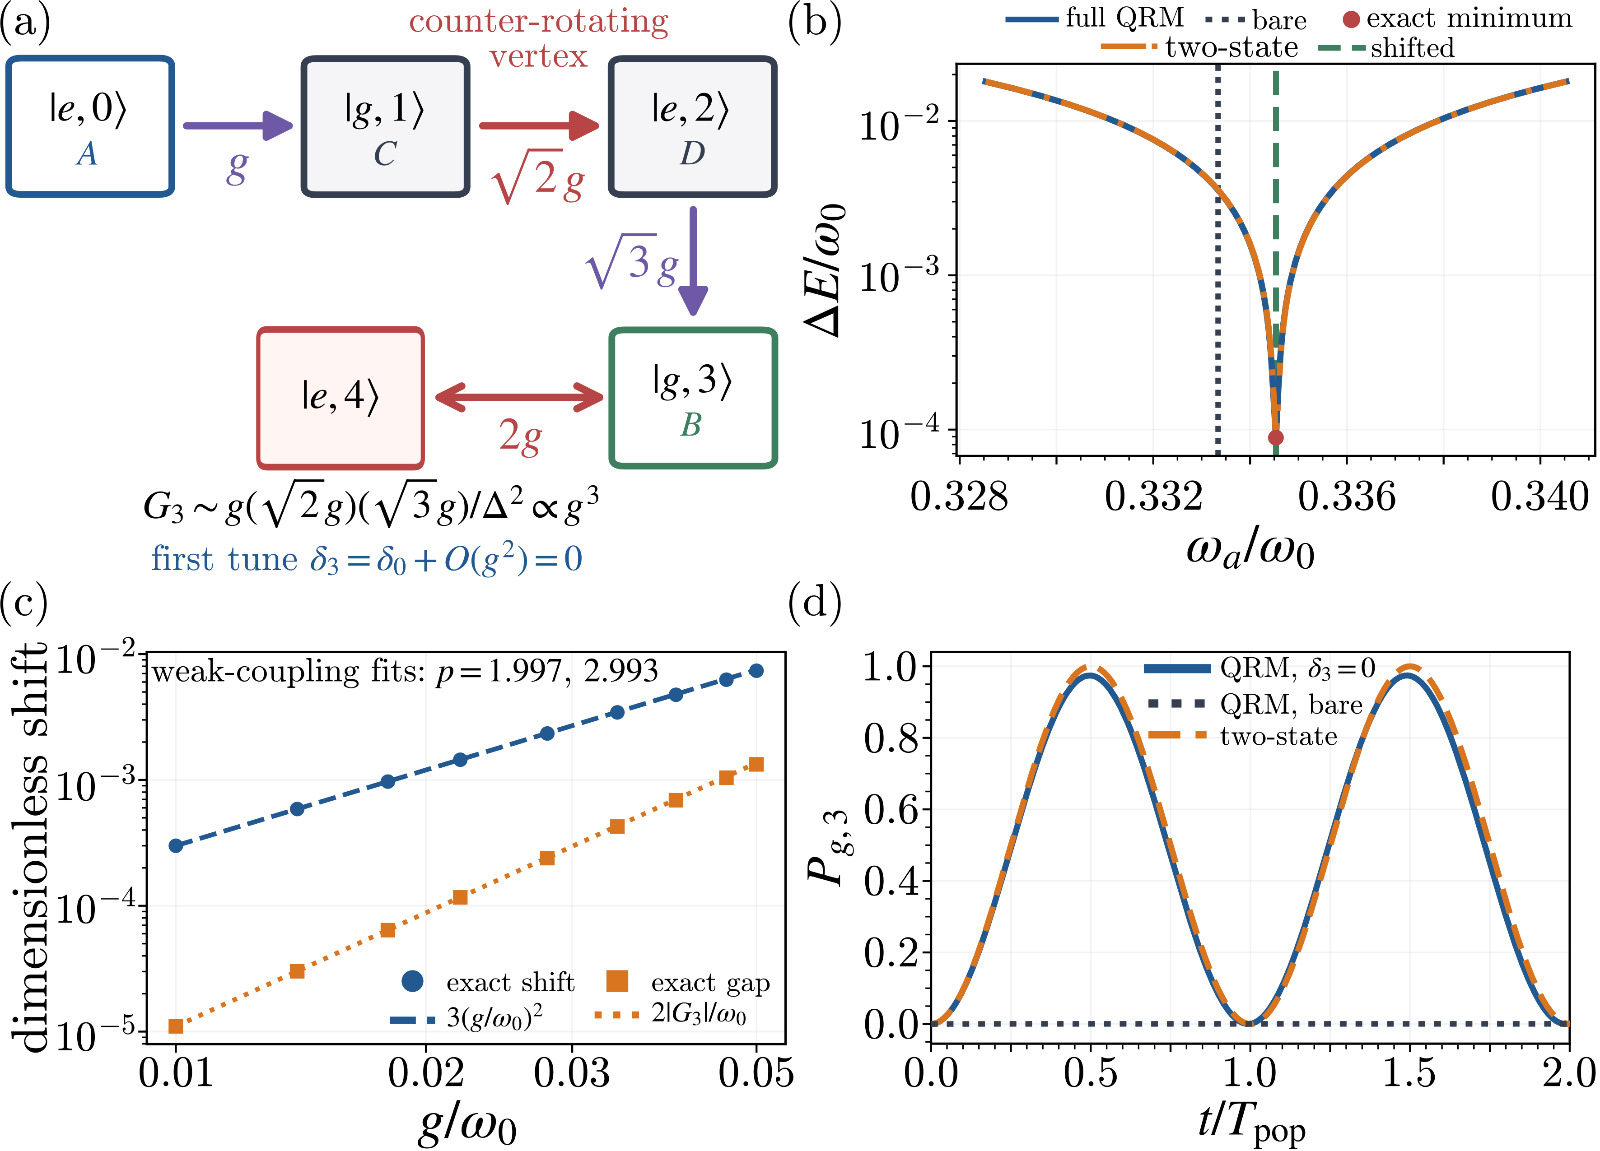

In [1]:
from hashlib import sha256
import shutil
from pathlib import Path
from IPython.display import Image, display

asset_pdf = Path("assets/manuscript/N05_MF1.pdf")
asset_jpeg = Path("assets/manuscript/N05_MF1.jpeg")
target_dir = Path("figures/manuscript")
target_dir.mkdir(parents=True, exist_ok=True)
target_pdf = target_dir / "N05_MF1.pdf"
target_jpeg = target_dir / "N05_MF1.jpeg"
shutil.copy2(asset_pdf, target_pdf)
shutil.copy2(asset_jpeg, target_jpeg)
assert sha256(asset_pdf.read_bytes()).hexdigest() == "f3054219fdd53a90af062243a1102c0a1364bb7328302bb2f7597192cb1fca71"
assert sha256(target_pdf.read_bytes()).hexdigest() == "f3054219fdd53a90af062243a1102c0a1364bb7328302bb2f7597192cb1fca71"
display(Image(filename=str(target_jpeg), width=950))

## Contents

1. Model, discovery workflow, symmetry, and analytical reference  
2. Imports and reproducibility information  
3. Data and figure directories  
4. Numerical parameters  
5. Operators, bare states, and parity  
6. Full Hamiltonian and analytical functions  
7. Exact avoided-crossing doublet  
8. Spectrum scan  
9. Exact resonance and minimum gap  
10. Avoided crossing and resolved gap profile  
11. Oscillator-cutoff convergence  
12. Coupling sweep  
13. Scaling exponents  
14. Quantitative spectral errors  
15. Spectroscopic conclusions  
16. Exact and effective time evolution  
17. Reconstruction and virtual populations  
18. Long-time accumulation of effective-model errors  
19. Bare preparation, dressed preparation, and initial slip  
20. Complementary physical views of the different methods  
21. Effective reductions for control design and error mitigation  
22. Static Floquet--Sambe and modulation-assisted resonance  
23. Validity map and error budget  
24. Pitfall laboratory  
25. Physics exercises  
26. Validated conclusions

## 1. Model, discovery workflow, symmetry, and analytical reference

We use the quantum Rabi Hamiltonian

$$
\hat H_{\mathrm R}
=
\omega_a \hat a^\dagger \hat a
+
\frac{\omega_0}{2}\hat\sigma_z
+
g(\hat a+\hat a^\dagger)
(\hat\sigma_++\hat\sigma_-).
$$

The uncoupled energies are

$$
E_{e,n}^{(0)}
=
n\omega_a+\frac{\omega_0}{2},
\qquad
E_{g,n}^{(0)}
=
n\omega_a-\frac{\omega_0}{2}.
$$

Near the three-photon condition, the retained states are

$$
\lvert A\rangle=\lvert e,0\rangle,
\qquad
\lvert B\rangle=\lvert g,3\rangle,
$$

with bare mismatch

$$
\delta_0
=
E_A^{(0)}-E_B^{(0)}
=
\omega_0-3\omega_a.
$$

We also define

$$
\Delta=\omega_0-\omega_a,
\qquad
\Sigma=\omega_0+\omega_a.
$$

Frequencies are measured in units of $\omega_0$. Time is therefore measured in units of $1/\omega_0$; no dimensional unit such as seconds is implied.

### 1.1 Discovering the interaction before knowing its form

An effective interaction need not be guessed in advance. For a static
Hamiltonian

$$
\hat H=\hat H_0+\hat V,
$$

a practical discovery procedure is:

$$
\text{symmetry}
\longrightarrow
\text{connectivity graph}
\longrightarrow
\text{near-degenerate states}
\longrightarrow
\text{shortest allowed path}
\longrightarrow
\text{retained block}.
$$

The eigenstates of $\hat H_0$ form the vertices of a graph. Two vertices
are connected when

$$
\langle\mu|\hat V|\nu\rangle\neq0.
$$

In the Rabi model, each elementary interaction term flips the qubit and changes
the oscillator occupation by one. Starting from $|e,0\rangle$, the graph
generates

$$
|e,0\rangle
\rightarrow
|g,1\rangle
\rightarrow
|e,2\rangle
\rightarrow
|g,3\rangle
\rightarrow
|e,4\rangle
\rightarrow\cdots.
$$

A state connected at graph distance $k$ can first acquire an endpoint
coupling at order $g^k$. Comparing the bare energies then identifies the
candidate resonances. For the family $|e,0\rangle\leftrightarrow|g,n\rangle$,

$$
E_{e,0}^{(0)}=E_{g,n}^{(0)}
\quad\Longrightarrow\quad
\omega_0=n\omega_a.
$$

Connectivity and parity select odd $n$. The first candidates are
therefore the one-, three-, and five-photon resonances, appearing at
first, third, and fifth order, respectively.

Projection or a resolvent expansion is then a direct way to enumerate
the virtual paths and their denominators. A Schrieffer--Wolff
transformation is a natural next step when a Hermitian retained-space
Hamiltonian and dressed control or measurement operators are required.

In [2]:
from collections import deque

def rabi_connectivity_candidates(max_photon_number: int = 7):
    """Enumerate candidate resonances reachable from |e,0> in the Rabi graph."""
    start = ("e", 0)
    queue = deque([start])
    distance = {start: 0}
    predecessor = {start: None}

    def neighbours(state):
        qubit, n = state
        flipped = "g" if qubit == "e" else "e"
        output = []
        if n + 1 <= max_photon_number:
            output.append((flipped, n + 1))
        if n - 1 >= 0:
            output.append((flipped, n - 1))
        return output

    while queue:
        state = queue.popleft()
        for neighbour in neighbours(state):
            if neighbour not in distance:
                distance[neighbour] = distance[state] + 1
                predecessor[neighbour] = state
                queue.append(neighbour)

    candidates = []
    for state, order in distance.items():
        qubit, n = state
        if qubit == "g" and n > 0:
            path = []
            current = state
            while current is not None:
                path.append(current)
                current = predecessor[current]
            path.reverse()
            candidates.append(
                {
                    "state": state,
                    "order": order,
                    "omega_a_over_omega_0": 1.0 / n,
                    "path": path,
                }
            )

    return sorted(candidates, key=lambda item: item["order"])


discovered_candidates = rabi_connectivity_candidates(max_photon_number=7)

print("Candidate | graph order | bare omega_a/omega_0 | shortest path")
for item in discovered_candidates:
    state_label = f"|{item['state'][0]},{item['state'][1]}>"
    path_label = " -> ".join(
        f"|{qubit},{number}>" for qubit, number in item["path"]
    )
    print(
        f"{state_label:9s} | "
        f"{item['order']:11d} | "
        f"{item['omega_a_over_omega_0']:21.6f} | "
        f"{path_label}"
    )

Candidate | graph order | bare omega_a/omega_0 | shortest path
|g,1>     |           1 |              1.000000 | |e,0> -> |g,1>
|g,3>     |           3 |              0.333333 | |e,0> -> |g,1> -> |e,2> -> |g,3>
|g,5>     |           5 |              0.200000 | |e,0> -> |g,1> -> |e,2> -> |g,3> -> |e,4> -> |g,5>
|g,7>     |           7 |              0.142857 | |e,0> -> |g,1> -> |e,2> -> |g,3> -> |e,4> -> |g,5> -> |e,6> -> |g,7>


### 1.2 Parity and the virtual pathway

The Rabi parity operator is taken to be

$$
\hat\Pi
=
-(-1)^{\hat n}\hat\sigma_z.
$$

Both target states have parity $-1$. They can therefore hybridize without breaking the symmetry.

The shortest virtual pathway is

$$
\lvert e,0\rangle
\xrightarrow{\;g\;}
\lvert g,1\rangle
\xrightarrow{\;\sqrt{2}g\;}
\lvert e,2\rangle
\xrightarrow{\;\sqrt{3}g\;}
\lvert g,3\rangle.
$$

The middle step is generated by the counter-rotating operator

$$
\hat a^\dagger\hat\sigma_+.
$$

Consequently, the ordinary Jaynes--Cummings rotating-wave approximation removes the essential middle vertex and predicts

$$
G_3^{\mathrm{RWA}}=0.
$$

The counter-rotating interaction is therefore not merely a correction to an existing three-photon process. It is required for the process to exist.

### 1.3 Second-order level shifts and the corrected resonance

The state $\lvert A\rangle=\lvert e,0\rangle$ couples at first order only to

$$
\lvert C\rangle=\lvert g,1\rangle,
$$

with matrix element $g$ and denominator

$$
E_A^{(0)}-E_C^{(0)}=\Delta.
$$

Its second-order shift is therefore

$$
\delta E_A^{(2)}
=
\frac{g^2}{\Delta}.
$$

The state $\lvert B\rangle=\lvert g,3\rangle$ couples to

$$
\lvert D\rangle=\lvert e,2\rangle,
\qquad
\lvert F\rangle=\lvert e,4\rangle,
$$

with matrix elements $\sqrt{3}g$ and $2g$. The corresponding denominators are $-\Delta$ and $-\Sigma$, giving

$$
\delta E_B^{(2)}
=
-\frac{3g^2}{\Delta}
-
\frac{4g^2}{\Sigma}.
$$

Notice that $\lvert e,4\rangle$ does not belong to the shortest endpoint pathway, but it contributes to the self-energy of $\lvert g,3\rangle$. Omitting it gives the wrong resonance position.

The effective detuning is

$$
\delta_3(\omega_a)
=
\omega_0-3\omega_a
+
4g^2
\left(
\frac{1}{\Delta}
+
\frac{1}{\Sigma}
\right)
+
O(g^4).
$$

Expanding the root of $\delta_3=0$ around $\omega_a=\omega_0/3$ gives

$$
\omega_a^{\mathrm{res}}
=
\frac{\omega_0}{3}
+
\frac{3g^2}{\omega_0}
+
O(g^4).
$$

### 1.4 Third-order endpoint coupling

The unique shortest pathway contains three elementary vertices. A quasi-degenerate third-order calculation gives the canonical retained-space matrix element

$$
G_3
=
\langle B|\hat H_{\mathrm{eff}}|A\rangle
=
-\frac{\sqrt{6}\,g^3}{2\omega_a\Delta}
+
O(g^5).
$$

At the leading crossing $\omega_a=\omega_0/3$,

$$
G_3
=
-\frac{\sqrt{6}\,g^3}{4\omega_a^2}
=
-\frac{9\sqrt{6}\,g^3}{4\omega_0^2}.
$$

The sign depends on the phase convention chosen for the retained basis. The invariant quantities are

$$
|G_3|,
\qquad
\Delta_{\mathrm{gap}}^{(3\gamma)}=2|G_3|,
$$

and the reconstructed physical observables.

The crucial order hierarchy is

$$
\omega_a^{\mathrm{res}}-\frac{\omega_0}{3}
=
O(g^2),
\qquad
\Delta_{\mathrm{gap}}^{(3\gamma)}
=
O(g^3).
$$

The resonance displacement is parametrically larger than the gap. Retaining the cubic coupling while imposing only the bare condition $\omega_0=3\omega_a$ is therefore order inconsistent.

### 1.5 Effective two-state dynamics

In the ordered basis $\{\lvert A\rangle,\lvert B\rangle\}$, the effective Hamiltonian is

$$
\hat H_{\mathrm{eff},3}
=
\bar E_3\hat I_3
+
\frac{\delta_3}{2}\hat\tau_z
+
G_3\hat\tau_+
+
G_3^*\hat\tau_-.
$$

After removing the mean energy, the generalized oscillation frequency is

$$
\Omega_3
=
\sqrt{\delta_3^2+4|G_3|^2}.
$$

Starting from $\lvert A\rangle$, the ideal retained-space target population is

$$
P_B^{\mathrm{eff}}(t)
=
\frac{4|G_3|^2}{\delta_3^2+4|G_3|^2}
\sin^2
\left(
\frac{\Omega_3t}{2}
\right).
$$

At resonance,

$$
P_B^{\mathrm{eff}}(t)=\sin^2(|G_3|t),
\qquad
T_{\mathrm{pop}}=\frac{\pi}{|G_3|}.
$$

Appreciable transfer requires approximately

$$
|\delta_3|\lesssim |G_3|.
$$

### 1.6 Leading reconstruction of the laboratory states

The retained amplitudes do not by themselves give the bare laboratory populations. Through second order, a canonical unitary reconstruction gives

$$
\begin{aligned}
|A\rangle_{\mathrm{rec}}
={}&
\left(
1-\frac{g^2}{2\Delta^2}
\right)|A\rangle
+
\frac{g}{\Delta}|g,1\rangle
-
\frac{\sqrt{2}g^2}{2\omega_a\Delta}|e,2\rangle
+
O(g^3),
\end{aligned}
$$

and

$$
\begin{aligned}
|B\rangle_{\mathrm{rec}}
={}&
\left[
1-\frac{1}{2}
\left(
\frac{3g^2}{\Delta^2}
+
\frac{4g^2}{\Sigma^2}
\right)
\right]|B\rangle
\\
&-
\frac{\sqrt{3}g}{\Delta}|e,2\rangle
-
\frac{2g}{\Sigma}|e,4\rangle
-
\frac{\sqrt{6}g^2}{2\omega_a\Delta}|g,1\rangle
+
\frac{\sqrt{5}g^2}{\omega_a\Sigma}|g,5\rangle
+
O(g^3).
\end{aligned}
$$

These terms distinguish virtual dressing from uncontrolled leakage. A bare target population below one does not by itself imply failure of the effective model: part of the normalized physical state can reside in the perturbatively reconstructed virtual components.

## 2. Imports and reproducibility information

The numerical calculations use QuTiP, NumPy, SciPy, and Matplotlib.
Package versions are printed so that changes in numerical behavior can
be traced to the computational environment.

In [3]:
from pathlib import Path
import json
import platform
import sys
import warnings
import logging
from itertools import cycle

import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.ticker import NullFormatter
from scipy.optimize import minimize_scalar, root_scalar
from scipy.special import jv

import qutip as qt

PLOT_STYLE = ["science", "notebook", "no-latex"]

# Some legacy STIX font tables carry unusual timestamps. fontTools may report
# them while Matplotlib embeds fonts, but they do not affect the calculations.
logging.getLogger("fontTools.ttLib.tables._h_e_a_d").setLevel(logging.ERROR)

SCALING_XTICKS = [0.01, 0.02, 0.03, 0.05]
SCALING_XTICK_LABELS = ["0.01", "0.02", "0.03", "0.05"]

def apply_scaling_xticks(ax):
    """Use compact readable ticks on the logarithmic coupling axis."""
    ax.set_xticks(SCALING_XTICKS)
    ax.set_xticklabels(SCALING_XTICK_LABELS)
    ax.xaxis.set_minor_formatter(NullFormatter())


plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 350,
    "font.size": 9.5,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "mathtext.fontset": "stix",
})

print(f"Python      : {platform.python_version()}")
print(f"NumPy       : {np.__version__}")
print(f"QuTiP       : {qt.__version__}")
print(f"SciencePlots: installed")

Python      : 3.11.9
NumPy       : 2.3.2
QuTiP       : 5.2.0
SciencePlots: installed


## 3. Data and figure directories

Numerical arrays are written to `data/`. Figures are written to
`figures/` in both PDF and PNG formats. Plotting cells read the saved
arrays so that figure generation can be repeated without rerunning the
spectral calculations.

In [4]:
NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR / "data"
MANUSCRIPT_FIGURE_DIR = NOTEBOOK_DIR / "figures" / "manuscript"
FIGURE_DIR = NOTEBOOK_DIR / "figures" / "notebook"

for directory in (DATA_DIR, MANUSCRIPT_FIGURE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

## 4. Numerical parameters

We set $\omega_0=1$. The first detailed scan uses $g/\omega_0=0.02$, matching the weak-coupling scale used in the earlier notebook, but without the unnecessary factor of $2\pi$.

The oscillator cutoff must exceed the largest bare state that contributes to the calculation. The target state contains three photons, the second-order shift involves $\lvert e,4\rangle$, and the second-order reconstruction later involves $\lvert g,5\rangle$. We begin with $N_{\mathrm{cav}}=16$ and verify convergence explicitly.

In [5]:
# Main reader-editable controls.
DENSE_SCAN = False
RUN_DYNAMICS = True
RUN_DRIVEN_FLOQUET_EXTENSION = False
RUN_EXTENDED_PITFALLS = True

omega_0 = 1.0
g_reference = 0.02 * omega_0
N_cav_reference = 16

omega_a_bare = omega_0 / 3.0
scan_half_width = 0.006 * omega_0
number_of_scan_points = 401 if DENSE_SCAN else 241
dynamics_points = 12001 if DENSE_SCAN else 3001

print(f"omega_0              = {omega_0:.6f}")
print(f"g / omega_0          = {g_reference / omega_0:.4f}")
print(f"bare omega_a/omega_0 = {omega_a_bare / omega_0:.8f}")
print(f"oscillator cutoff    = {N_cav_reference}")
print(f"dense scan      = {DENSE_SCAN}")
print(f"run dynamics         = {RUN_DYNAMICS}")
print(f"run driven Floquet extension  = {RUN_DRIVEN_FLOQUET_EXTENSION}")

omega_0              = 1.000000
g / omega_0          = 0.0200
bare omega_a/omega_0 = 0.33333333
oscillator cutoff    = 16
dense scan      = False
run dynamics         = True
run driven Floquet extension  = False


## 5. Operators, bare states, and parity

QuTiP orders tensor factors in the same order in which they are supplied. We use

$$
\mathcal H
=
\mathcal H_{\mathrm{oscillator}}
\otimes
\mathcal H_{\mathrm{qubit}}.
$$

In QuTiP's standard Pauli-$z$ basis,

$$
\hat\sigma_z\lvert e\rangle=+\lvert e\rangle,
\qquad
\hat\sigma_z\lvert g\rangle=-\lvert g\rangle.
$$

We adopt the parity convention
$$
\hat\Pi
=
-(-1)^{\hat n}\hat\sigma_z.
$$
Under this convention, both target states have parity $-1$.

In [6]:
def build_operators(N_cav: int) -> dict[str, qt.Qobj]:
    """Construct all elementary operators in the composite Hilbert space."""
    a_cav = qt.destroy(N_cav)
    identity_cav = qt.qeye(N_cav)
    identity_qubit = qt.qeye(2)

    a = qt.tensor(a_cav, identity_qubit)
    number = a.dag() * a
    sigma_x = qt.tensor(identity_cav, qt.sigmax())
    sigma_z = qt.tensor(identity_cav, qt.sigmaz())
    sigma_plus = qt.tensor(identity_cav, qt.sigmap())
    sigma_minus = qt.tensor(identity_cav, qt.sigmam())
    identity = qt.tensor(identity_cav, identity_qubit)

    oscillator_parity = qt.Qobj(
        np.diag((-1.0) ** np.arange(N_cav)),
        dims=[[N_cav], [N_cav]],
    )
    parity = -qt.tensor(oscillator_parity, qt.sigmaz())

    return {
        "a": a,
        "number": number,
        "sigma_x": sigma_x,
        "sigma_z": sigma_z,
        "sigma_plus": sigma_plus,
        "sigma_minus": sigma_minus,
        "identity": identity,
        "parity": parity,
    }


def bare_state(N_cav: int, photon_number: int, qubit_label: str) -> qt.Qobj:
    """Return |e,n> or |g,n> using the oscillator-first tensor ordering."""
    if qubit_label not in {"e", "g"}:
        raise ValueError("qubit_label must be either 'e' or 'g'.")

    if photon_number >= N_cav:
        raise ValueError(
            f"photon_number={photon_number} is outside N_cav={N_cav}."
        )

    qubit_index = 0 if qubit_label == "e" else 1
    return qt.tensor(
        qt.basis(N_cav, photon_number),
        qt.basis(2, qubit_index),
    )


operators = build_operators(N_cav_reference)

ket_A = bare_state(N_cav_reference, photon_number=0, qubit_label="e")
ket_B = bare_state(N_cav_reference, photon_number=3, qubit_label="g")

parity_A = qt.expect(operators["parity"], ket_A)
parity_B = qt.expect(operators["parity"], ket_B)

print(f"Parity of |e,0> : {parity_A:+.1f}")
print(f"Parity of |g,3> : {parity_B:+.1f}")

assert np.isclose(parity_A, parity_B)

Parity of |e,0> : -1.0
Parity of |g,3> : -1.0


The equality of the two parity eigenvalues confirms that the three-photon transition is symmetry allowed. By contrast, a state of opposite parity cannot hybridize with $\lvert e,0\rangle$ unless the symmetry is broken.

## 6. Full Hamiltonian and analytical functions

The functions below remain deliberately short. They represent individual physical steps rather than hiding the calculation inside a large simulation object.

The analytical resonance is obtained by solving $\delta_3(\omega_a)=0$, retaining the $\omega_a$-dependence of both $\Delta$ and $\Sigma$. We also keep the leading expansion

$$
\omega_a^{\mathrm{res}}
=
\frac{\omega_0}{3}
+
\frac{3g^2}{\omega_0}
+
O(g^4)
$$

for comparison.

In [7]:
def rabi_hamiltonian(
    omega_a: float,
    omega_0: float,
    g: float,
    operators: dict[str, qt.Qobj],
) -> qt.Qobj:
    """Return the full quantum Rabi Hamiltonian."""
    return (
        omega_a * operators["number"]
        + 0.5 * omega_0 * operators["sigma_z"]
        + g * (operators["a"] + operators["a"].dag()) * operators["sigma_x"]
    )


def delta_three_photon(omega_a: float, omega_0: float, g: float) -> float:
    """Second-order effective detuning for the three-photon doublet."""
    Delta = omega_0 - omega_a
    Sigma = omega_0 + omega_a
    return (
        omega_0
        - 3.0 * omega_a
        + 4.0 * g**2 * (1.0 / Delta + 1.0 / Sigma)
    )


def shifted_resonance_root(omega_0: float, g: float) -> float:
    """Solve delta_3(omega_a)=0 near omega_0/3."""
    lower = 0.25 * omega_0
    upper = 0.42 * omega_0
    solution = root_scalar(
        delta_three_photon,
        args=(omega_0, g),
        bracket=(lower, upper),
        method="brentq",
    )
    if not solution.converged:
        raise RuntimeError("The perturbative resonance root did not converge.")
    return float(solution.root)


def shifted_resonance_leading(omega_0: float, g: float) -> float:
    """Leading expansion of the corrected resonance."""
    return omega_0 / 3.0 + 3.0 * g**2 / omega_0


def canonical_three_photon_coupling(
    omega_a: float,
    omega_0: float,
    g: float,
) -> float:
    """Canonical third-order matrix element G_3."""
    Delta = omega_0 - omega_a
    return -np.sqrt(6.0) * g**3 / (2.0 * omega_a * Delta)


def analytical_minimum_gap(
    omega_a: float,
    omega_0: float,
    g: float,
) -> float:
    """Avoided-crossing gap 2|G_3|."""
    return 2.0 * abs(canonical_three_photon_coupling(omega_a, omega_0, g))


omega_a_shifted_root = shifted_resonance_root(omega_0, g_reference)
omega_a_shifted_leading = shifted_resonance_leading(omega_0, g_reference)
gap_prediction = analytical_minimum_gap(
    omega_a_shifted_root,
    omega_0,
    g_reference,
)

print(f"bare resonance                 : {omega_a_bare:.10f}")
print(f"leading shifted resonance      : {omega_a_shifted_leading:.10f}")
print(f"root of second-order delta_3   : {omega_a_shifted_root:.10f}")
print(f"predicted minimum gap 2|G_3|   : {gap_prediction:.10e}")

bare resonance                 : 0.3333333333
leading shifted resonance      : 0.3345333333
root of second-order delta_3   : 0.3345344172
predicted minimum gap 2|G_3|   : 8.8023616541e-05


## 7. Identifying the exact avoided-crossing doublet

Near the avoided crossing, the exact eigenstates are mixtures of $\lvert A\rangle$, $\lvert B\rangle$, and virtual states. Selecting eigenstates by a fixed eigenvalue index can therefore be unreliable.

Instead, define the retained-space projector
$$
\hat P_3
=
\lvert A\rangle\langle A\rvert
+
\lvert B\rangle\langle B\rvert.
$$

For each value of $\omega_a$, we select the two exact eigenstates with the largest retained weight
$$
w_j
=
\langle\psi_j|\hat P_3|\psi_j\rangle.
$$

This is both physically meaningful and easy to diagnose: if the selected weights become small, the two-state description is no longer isolated.

In [8]:
def identify_three_photon_doublet(
    omega_a: float,
    omega_0: float,
    g: float,
    N_cav: int,
) -> dict[str, np.ndarray | float]:
    """Diagonalize the full model and select the two states with largest P_3 weight."""
    local_operators = build_operators(N_cav)
    local_A = bare_state(N_cav, photon_number=0, qubit_label="e")
    local_B = bare_state(N_cav, photon_number=3, qubit_label="g")
    projector_P = qt.ket2dm(local_A) + qt.ket2dm(local_B)

    H = rabi_hamiltonian(omega_a, omega_0, g, local_operators)
    eigenvalues, eigenstates = H.eigenstates()

    retained_weights = np.array(
        [float(np.real(qt.expect(projector_P, state))) for state in eigenstates]
    )
    selected_indices = np.argsort(retained_weights)[-2:]
    selected_indices = selected_indices[
        np.argsort(np.asarray(eigenvalues)[selected_indices])
    ]

    selected_energies = np.asarray(eigenvalues, dtype=float)[selected_indices]
    selected_states = [eigenstates[index] for index in selected_indices]
    selected_weights = retained_weights[selected_indices]

    overlap_A = np.array(
        [abs(local_A.overlap(state)) ** 2 for state in selected_states],
        dtype=float,
    )
    overlap_B = np.array(
        [abs(local_B.overlap(state)) ** 2 for state in selected_states],
        dtype=float,
    )

    return {
        "energies": selected_energies,
        "gap": float(selected_energies[1] - selected_energies[0]),
        "retained_weights": selected_weights,
        "overlap_A": overlap_A,
        "overlap_B": overlap_B,
    }


check_doublet = identify_three_photon_doublet(
    omega_a=omega_a_shifted_root,
    omega_0=omega_0,
    g=g_reference,
    N_cav=N_cav_reference,
)

print("Selected energies        :", check_doublet["energies"])
print("Exact gap                :", check_doublet["gap"])
print("Retained-space weights   :", check_doublet["retained_weights"])
print("|<A|psi_j>|^2            :", check_doublet["overlap_A"])
print("|<B|psi_j>|^2            :", check_doublet["overlap_B"])

Selected energies        : [0.50056161 0.50065023]
Exact gap                : 8.86150955139442e-05
Retained-space weights   : [0.99796027 0.99757022]
|<A|psi_j>|^2            : [0.57235487 0.42674594]
|<B|psi_j>|^2            : [0.4256054  0.57082428]


## 8. Spectrum scan around the avoided crossing

We now scan $\omega_a$ around the perturbatively shifted resonance. For visual clarity, we subtract the mean energy of the selected doublet,
$$
\bar E=\frac{E_++E_-}{2},
$$
and plot the centered branches $E_\pm-\bar E$.

The calculation also stores the retained-space weights and bare-state characters. These diagnostics prevent a visually plausible avoided crossing from being accepted without checking that it is actually the desired three-photon doublet.

In [9]:
omega_scan = np.linspace(
    omega_a_shifted_root - scan_half_width,
    omega_a_shifted_root + scan_half_width,
    number_of_scan_points,
)

energy_lower = np.empty_like(omega_scan)
energy_upper = np.empty_like(omega_scan)
exact_gap_scan = np.empty_like(omega_scan)
weight_lower = np.empty_like(omega_scan)
weight_upper = np.empty_like(omega_scan)
A_character_lower = np.empty_like(omega_scan)
A_character_upper = np.empty_like(omega_scan)
B_character_lower = np.empty_like(omega_scan)
B_character_upper = np.empty_like(omega_scan)

for index, omega_a in enumerate(omega_scan):
    doublet = identify_three_photon_doublet(
        omega_a=omega_a,
        omega_0=omega_0,
        g=g_reference,
        N_cav=N_cav_reference,
    )

    energies = doublet["energies"]
    mean_energy = 0.5 * (energies[0] + energies[1])

    energy_lower[index] = energies[0] - mean_energy
    energy_upper[index] = energies[1] - mean_energy
    exact_gap_scan[index] = doublet["gap"]
    weight_lower[index], weight_upper[index] = doublet["retained_weights"]
    A_character_lower[index], A_character_upper[index] = doublet["overlap_A"]
    B_character_lower[index], B_character_upper[index] = doublet["overlap_B"]

scan_file = DATA_DIR / "N05_D1.csv"
scan_array = np.column_stack(
    [
        omega_scan,
        energy_lower,
        energy_upper,
        exact_gap_scan,
        weight_lower,
        weight_upper,
        A_character_lower,
        A_character_upper,
        B_character_lower,
        B_character_upper,
    ]
)

np.savetxt(
    scan_file,
    scan_array,
    delimiter=",",
    header=(
        "omega_a,energy_lower_centered,energy_upper_centered,exact_gap,"
        "retained_weight_lower,retained_weight_upper,"
        "A_character_lower,A_character_upper,"
        "B_character_lower,B_character_upper"
    ),
    comments="",
)

print(
    "Minimum selected retained weight: "
    f"{min(weight_lower.min(), weight_upper.min()):.6f}"
)

Minimum selected retained weight: 0.996390


## 9. Numerical minimization of the exact gap

The grid scan gives a first estimate of the crossing. We refine it by minimizing the exact selected-doublet gap in a small bracket around the grid minimum.

The numerical resonance is defined operationally as
$$
\omega_{a,\mathrm{exact}}^{\mathrm{res}}
=
\operatorname*{arg\,min}_{\omega_a}
\left[E_+(\omega_a)-E_-(\omega_a)\right].
$$

This definition is representation independent and directly connected to spectroscopy.

In [10]:
def exact_three_photon_gap(
    omega_a: float,
    omega_0: float,
    g: float,
    N_cav: int,
) -> float:
    """Return the exact gap of the selected three-photon doublet."""
    return float(
        identify_three_photon_doublet(
            omega_a=omega_a,
            omega_0=omega_0,
            g=g,
            N_cav=N_cav,
        )["gap"]
    )


grid_minimum_index = int(np.argmin(exact_gap_scan))
grid_resonance = float(omega_scan[grid_minimum_index])

local_spacing = float(omega_scan[1] - omega_scan[0])
lower_bound = grid_resonance - 4.0 * local_spacing
upper_bound = grid_resonance + 4.0 * local_spacing

minimization = minimize_scalar(
    exact_three_photon_gap,
    bounds=(lower_bound, upper_bound),
    args=(omega_0, g_reference, N_cav_reference),
    method="bounded",
    options={"xatol": 1e-12},
)

if not minimization.success:
    raise RuntimeError("Exact-gap minimization did not converge.")

omega_a_exact_resonance = float(minimization.x)
exact_minimum_gap = float(minimization.fun)

print(f"bare resonance                     : {omega_a_bare:.12f}")
print(f"leading shifted resonance          : {omega_a_shifted_leading:.12f}")
print(f"second-order root                  : {omega_a_shifted_root:.12f}")
print(f"exact minimum-gap resonance        : {omega_a_exact_resonance:.12f}")
print()
print(f"analytical gap 2|G_3|              : {gap_prediction:.12e}")
print(f"exact minimum gap                  : {exact_minimum_gap:.12e}")
print(
    "relative gap error                  : "
    f"{abs(exact_minimum_gap - gap_prediction) / exact_minimum_gap:.3e}"
)

bare resonance                     : 0.333333333333
leading shifted resonance          : 0.334533333333
second-order root                  : 0.334534417235
exact minimum-gap resonance        : 0.334530109601

analytical gap 2|G_3|              : 8.802361654099e-05
exact minimum gap                  : 8.766951417660e-05
relative gap error                  : 4.039e-03


## 10. Plot the saved avoided-crossing data

The plotting cell reads the CSV file written above. This makes it possible to regenerate the figure without repeating the diagonalization.

The vertical markers distinguish:

- the bare condition $\omega_a=\omega_0/3$;
- the root of the second-order effective detuning;
- the exact minimum-gap resonance.

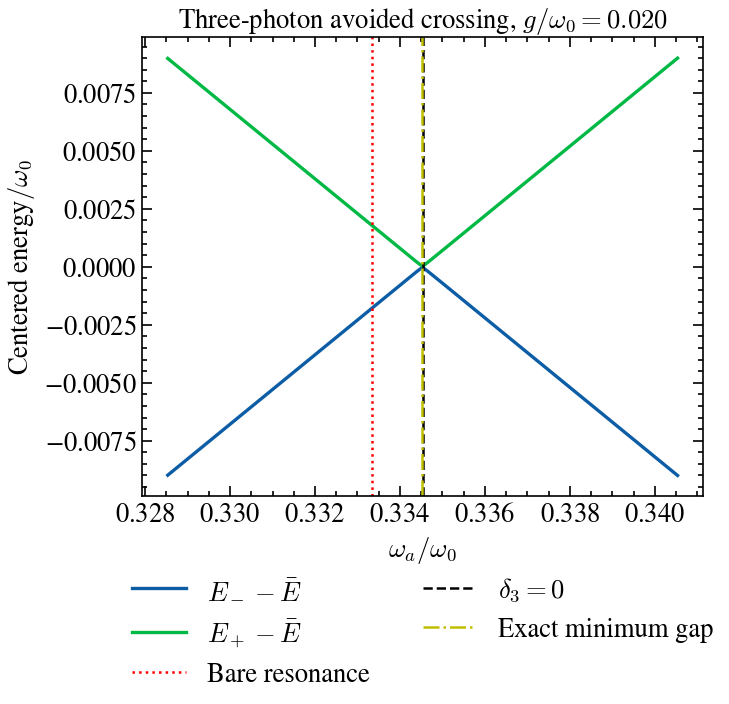

In [11]:
saved_scan = np.genfromtxt(
    scan_file,
    delimiter=",",
    names=True,
)

with plt.style.context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(6.2, 6.2))

    x_values = saved_scan["omega_a"] / omega_0
    ax.plot(
        x_values,
        saved_scan["energy_lower_centered"] / omega_0,
        label=r"$E_- - \bar E$",
    )
    ax.plot(
        x_values,
        saved_scan["energy_upper_centered"] / omega_0,
        label=r"$E_+ - \bar E$",
    )

    ax.axvline(
        omega_a_bare / omega_0,
        linestyle=":",color='r',
        linewidth=1.5,
        label="Bare resonance",
    )
    ax.axvline(
        omega_a_shifted_root / omega_0,
        linestyle="--",color='k',
        linewidth=1.5,
        label=r"$\delta_3=0$",
    )
    ax.axvline(
        omega_a_exact_resonance / omega_0,
        linestyle="-.",color='y',
        linewidth=1.5,
        label="Exact minimum gap",
    )

    ax.set_xlabel(r"$\omega_a/\omega_0$")
    ax.set_ylabel(r"Centered energy$/\omega_0$")
    ax.set_title(
        rf"Three-photon avoided crossing, $g/\omega_0={g_reference / omega_0:.3f}$"
    )
    ax.legend(
            frameon=False,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.15),
            ncol=2,
            borderaxespad=0.0,
        )

    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / "N05_F1.pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        FIGURE_DIR / "N05_F1.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

The broad spectrum displays the resonance displacement, but the cubic
minimum gap is much smaller than the vertical scale of the centered
branches. A direct gap profile resolves the avoided crossing and allows
a comparison with the effective two-state prediction

$$
\Delta_{\mathrm{eff}}(\omega_a)
=
\sqrt{\delta_3(\omega_a)^2+4|G_3(\omega_a)|^2}.
$$

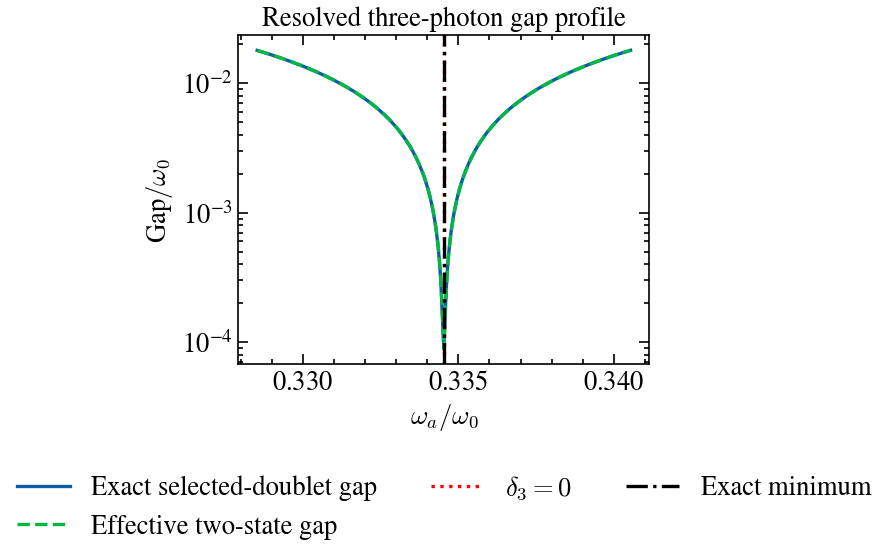

In [12]:
effective_gap_scan = np.array(
    [
        np.sqrt(
            delta_three_photon(omega_a, omega_0, g_reference) ** 2
            + 4.0
            * abs(
                canonical_three_photon_coupling(
                    omega_a,
                    omega_0,
                    g_reference,
                )
            )
            ** 2
        )
        for omega_a in omega_scan
    ]
)

gap_profile_file = DATA_DIR / "N05_D2.csv"
np.savetxt(
    gap_profile_file,
    np.column_stack(
        [omega_scan, exact_gap_scan, effective_gap_scan]
    ),
    delimiter=",",
    header="omega_a,exact_gap,effective_two_state_gap",
    comments="",
)

with plt.style.context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(6.2, 5.2))

    ax.plot(
        omega_scan / omega_0,
        exact_gap_scan / omega_0,
        label="Exact selected-doublet gap",
    )
    ax.plot(
        omega_scan / omega_0,
        effective_gap_scan / omega_0,
        linestyle="--",
        label="Effective two-state gap",
    )
    ax.axvline(
        omega_a_shifted_root / omega_0,
        linestyle=":",color='r',
        label=r"$\delta_3=0$",
    )
    ax.axvline(
        omega_a_exact_resonance / omega_0,
        linestyle="-.", color = 'k',
        label="Exact minimum",
    )

    ax.set_xlabel(r"$\omega_a/\omega_0$")
    ax.set_ylabel(r"Gap$/\omega_0$")
    ax.set_yscale("log")
    ax.set_title("Resolved three-photon gap profile")
    ax.legend(frameon=False,loc="upper center",bbox_to_anchor=(0.5, -0.30),ncol=3,borderaxespad=0.0,
    )

    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / "N05_F2.pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        FIGURE_DIR / "N05_F2.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 11. Oscillator-cutoff convergence

A correct weak-coupling result should not depend materially on the oscillator truncation once all relevant virtual states are included.

We repeat the minimum-gap extraction for several values of $N_{\mathrm{cav}}$. The smallest meaningful cutoff must include at least $\lvert e,4\rangle$; the sequence below also checks stability after higher states are restored.

We monitor both:

$$
\omega_{a,\mathrm{exact}}^{\mathrm{res}}(N_{\mathrm{cav}})
\quad\text{and}\quad
\Delta_{\mathrm{gap}}(N_{\mathrm{cav}}).
$$

In [13]:
cutoff_values = np.array([6, 8, 10, 12, 14, 16, 20], dtype=int)

cutoff_resonances = np.empty(cutoff_values.size, dtype=float)
cutoff_gaps = np.empty(cutoff_values.size, dtype=float)
cutoff_min_weights = np.empty(cutoff_values.size, dtype=float)

for index, N_cav in enumerate(cutoff_values):
    local_scan = np.linspace(
        omega_a_shifted_root - 0.0015 * omega_0,
        omega_a_shifted_root + 0.0015 * omega_0,
        81,
    )
    local_gaps = np.array(
        [
            exact_three_photon_gap(
                omega_a,
                omega_0,
                g_reference,
                int(N_cav),
            )
            for omega_a in local_scan
        ]
    )
    local_minimum_index = int(np.argmin(local_gaps))
    local_center = float(local_scan[local_minimum_index])
    local_spacing = float(local_scan[1] - local_scan[0])

    local_minimization = minimize_scalar(
        exact_three_photon_gap,
        bounds=(
            local_center - 4.0 * local_spacing,
            local_center + 4.0 * local_spacing,
        ),
        args=(omega_0, g_reference, int(N_cav)),
        method="bounded",
        options={"xatol": 1e-12},
    )

    if not local_minimization.success:
        raise RuntimeError(
            f"Cutoff convergence failed for N_cav={N_cav}."
        )

    cutoff_resonances[index] = local_minimization.x
    cutoff_gaps[index] = local_minimization.fun

    local_doublet = identify_three_photon_doublet(
        omega_a=local_minimization.x,
        omega_0=omega_0,
        g=g_reference,
        N_cav=int(N_cav),
    )
    cutoff_min_weights[index] = np.min(
        local_doublet["retained_weights"]
    )

    print(
        f"N_cav={N_cav:2d} | "
        f"omega_res={cutoff_resonances[index]:.12f} | "
        f"gap={cutoff_gaps[index]:.12e} | "
        f"min P-weight={cutoff_min_weights[index]:.8f}"
    )

cutoff_file = DATA_DIR / "N05_D3.csv"
np.savetxt(
    cutoff_file,
    np.column_stack(
        [
            cutoff_values,
            cutoff_resonances,
            cutoff_gaps,
            cutoff_min_weights,
        ]
    ),
    delimiter=",",
    header="N_cav,omega_a_exact_resonance,exact_minimum_gap,minimum_retained_weight",
    comments="",
)


N_cav= 6 | omega_res=0.334530108093 | gap=8.766951542005e-05 | min P-weight=0.99776484
N_cav= 8 | omega_res=0.334530109679 | gap=8.766951417538e-05 | min P-weight=0.99776483
N_cav=10 | omega_res=0.334530109679 | gap=8.766951417538e-05 | min P-weight=0.99776483
N_cav=12 | omega_res=0.334530109679 | gap=8.766951417560e-05 | min P-weight=0.99776483
N_cav=14 | omega_res=0.334530109679 | gap=8.766951417560e-05 | min P-weight=0.99776483
N_cav=16 | omega_res=0.334530109679 | gap=8.766951417560e-05 | min P-weight=0.99776483
N_cav=20 | omega_res=0.334530109679 | gap=8.766951417560e-05 | min P-weight=0.99776483


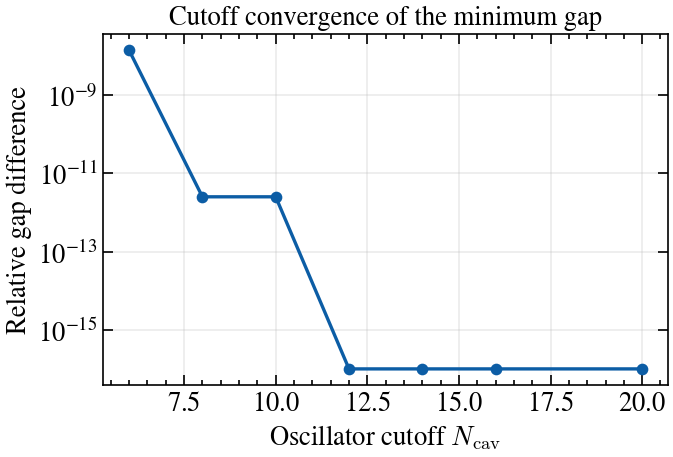

In [14]:
saved_cutoff = np.genfromtxt(
    cutoff_file,
    delimiter=",",
    names=True,
)

reference_gap_cutoff = saved_cutoff["exact_minimum_gap"][-1]
relative_gap_difference = np.abs(
    saved_cutoff["exact_minimum_gap"] - reference_gap_cutoff
) / reference_gap_cutoff

with plt.style.context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(5.8, 4.0))

    ax.semilogy(
        saved_cutoff["N_cav"],
        np.maximum(relative_gap_difference, 1e-16),
        marker="o",
    )
    ax.set_xlabel(r"Oscillator cutoff $N_{\mathrm{cav}}$")
    ax.set_ylabel("Relative gap difference")
    ax.set_title("Cutoff convergence of the minimum gap")
    ax.grid(alpha=0.25)

    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / "N05_F3.pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        FIGURE_DIR / "N05_F3.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

## 12. Coupling sweep: $g^2$ resonance displacement and $g^3$ gap

We now vary $g$ and repeat the exact minimum-gap calculation.

For each coupling, we record:

- the bare resonance $\omega_0/3$;
- the leading shifted resonance;
- the root of the second-order effective detuning;
- the exact minimum-gap resonance;
- the analytical gap $2|G_3|$;
- the exact minimum gap;
- the retained-space weight of the exact doublet.

The power-law exponents are fitted only in a declared weak-coupling subset. This avoids claiming an asymptotic scaling from points already outside its controlled regime.

In [15]:
coupling_values = omega_0 * np.array(
    [0.010, 0.014, 0.018, 0.022, 0.028, 0.034, 0.040, 0.046, 0.050]
)

exact_resonances = np.empty_like(coupling_values)
perturbative_roots = np.empty_like(coupling_values)
leading_resonances = np.empty_like(coupling_values)
exact_gaps = np.empty_like(coupling_values)
analytical_gaps = np.empty_like(coupling_values)
minimum_retained_weights = np.empty_like(coupling_values)

for index, g_value in enumerate(coupling_values):
    perturbative_root = shifted_resonance_root(omega_0, g_value)
    leading_root = shifted_resonance_leading(omega_0, g_value)

    # The search width grows mildly with the expected g^2 shift.
    local_half_width = max(
        8.0e-4 * omega_0,
        2.5 * abs(leading_root - omega_a_bare),
    )
    local_scan = np.linspace(
        perturbative_root - local_half_width,
        perturbative_root + local_half_width,
        101,
    )
    local_gaps = np.array(
        [
            exact_three_photon_gap(
                omega_a,
                omega_0,
                g_value,
                N_cav_reference,
            )
            for omega_a in local_scan
        ]
    )

    local_minimum_index = int(np.argmin(local_gaps))
    local_center = float(local_scan[local_minimum_index])
    local_spacing = float(local_scan[1] - local_scan[0])

    local_minimization = minimize_scalar(
        exact_three_photon_gap,
        bounds=(
            local_center - 4.0 * local_spacing,
            local_center + 4.0 * local_spacing,
        ),
        args=(omega_0, g_value, N_cav_reference),
        method="bounded",
        options={"xatol": 1e-12},
    )

    if not local_minimization.success:
        raise RuntimeError(
            f"Coupling sweep failed for g/omega_0={g_value / omega_0:.4f}."
        )

    exact_resonances[index] = local_minimization.x
    perturbative_roots[index] = perturbative_root
    leading_resonances[index] = leading_root
    exact_gaps[index] = local_minimization.fun
    analytical_gaps[index] = analytical_minimum_gap(
        perturbative_root,
        omega_0,
        g_value,
    )

    local_doublet = identify_three_photon_doublet(
        omega_a=local_minimization.x,
        omega_0=omega_0,
        g=g_value,
        N_cav=N_cav_reference,
    )
    minimum_retained_weights[index] = np.min(
        local_doublet["retained_weights"]
    )

    print(
        f"g/omega_0={g_value / omega_0:.3f} | "
        f"shift={exact_resonances[index] - omega_a_bare:.6e} | "
        f"gap={exact_gaps[index]:.6e} | "
        f"min P-weight={minimum_retained_weights[index]:.6f}"
    )

scaling_file = DATA_DIR / "N05_D4.csv"
np.savetxt(
    scaling_file,
    np.column_stack(
        [
            coupling_values,
            leading_resonances,
            perturbative_roots,
            exact_resonances,
            analytical_gaps,
            exact_gaps,
            minimum_retained_weights,
        ]
    ),
    delimiter=",",
    header=(
        "g,omega_a_leading_shifted,omega_a_delta3_root,"
        "omega_a_exact_resonance,analytical_gap,exact_gap,"
        "minimum_retained_weight"
    ),
    comments="",
)


g/omega_0=0.010 | shift=2.997978e-04 | gap=1.100661e-05 | min P-weight=0.999438
g/omega_0=0.014 | shift=5.872240e-04 | gap=3.015991e-05 | min P-weight=0.998901
g/omega_0=0.018 | shift=9.698828e-04 | gap=6.398159e-05 | min P-weight=0.998187
g/omega_0=0.022 | shift=1.447285e-03 | gap=1.165462e-04 | min P-weight=0.997299
g/omega_0=0.028 | shift=2.339676e-03 | gap=2.392351e-04 | min P-weight=0.995646
g/omega_0=0.034 | shift=3.441331e-03 | gap=4.260632e-04 | min P-weight=0.993617
g/omega_0=0.040 | shift=4.749193e-03 | gap=6.894135e-04 | min P-weight=0.991225
g/omega_0=0.046 | shift=6.259704e-03 | gap=1.040936e-03 | min P-weight=0.988484
g/omega_0=0.050 | shift=7.377329e-03 | gap=1.329654e-03 | min P-weight=0.986471


## 13. Extract the numerical scaling exponents

A power law $y\propto g^\alpha$ becomes

$$
\log y=\alpha\log g+\mathrm{constant}.
$$

Two fits answer slightly different questions and are therefore kept separately.

1. **Weak-coupling fit:** use only $g/\omega_0\le 0.03$. This is the cleaner
   asymptotic diagnostic and should approach the theoretical exponents $2$ and
   $3$.
2. **Manuscript finite-range fit:** fit the complete coupling interval displayed
   in the manuscript figure. This reproduces the reported finite-range slopes and
   makes the notebook-generated manuscript figure use exactly the same numerical
   claim as the article.

Keeping both prevents a manuscript-specific plotting choice from replacing the
more instructive asymptotic check.

In [16]:
saved_scaling = np.genfromtxt(
    scaling_file,
    delimiter=",",
    names=True,
)

g_ratio = saved_scaling["g"] / omega_0
weak_mask = g_ratio <= 0.03

exact_shift = (
    saved_scaling["omega_a_exact_resonance"] - omega_a_bare
)
leading_shift = (
    saved_scaling["omega_a_leading_shifted"] - omega_a_bare
)

# Asymptotic/learning diagnostic.
shift_fit_weak = np.polyfit(
    np.log(g_ratio[weak_mask]),
    np.log(exact_shift[weak_mask] / omega_0),
    deg=1,
)
gap_fit_weak = np.polyfit(
    np.log(g_ratio[weak_mask]),
    np.log(saved_scaling["exact_gap"][weak_mask] / omega_0),
    deg=1,
)

shift_exponent_weak = shift_fit_weak[0]
gap_exponent_weak = gap_fit_weak[0]

# Canonical article figure: fit the complete plotted finite range.
shift_fit_manuscript = np.polyfit(
    np.log(g_ratio),
    np.log(exact_shift / omega_0),
    deg=1,
)
gap_fit_manuscript = np.polyfit(
    np.log(g_ratio),
    np.log(saved_scaling["exact_gap"] / omega_0),
    deg=1,
)

shift_exponent_manuscript = shift_fit_manuscript[0]
gap_exponent_manuscript = gap_fit_manuscript[0]

# Backward-compatible aliases used by notebook-only asymptotic plots.
shift_exponent = shift_exponent_weak
gap_exponent = gap_exponent_weak

print("Weak-coupling asymptotic fit")
print(f"  resonance-shift exponent : {shift_exponent_weak:.6f}  (expected 2)")
print(f"  minimum-gap exponent     : {gap_exponent_weak:.6f}  (expected 3)")
print()
print("Canonical plotted-range fit")
print(f"  resonance-shift exponent : {shift_exponent_manuscript:.6f}")
print(f"  minimum-gap exponent     : {gap_exponent_manuscript:.6f}")

Weak-coupling asymptotic fit
  resonance-shift exponent : 1.995688  (expected 2)
  minimum-gap exponent     : 2.990670  (expected 3)

Canonical plotted-range fit
  resonance-shift exponent : 1.990390
  minimum-gap exponent     : 2.979250


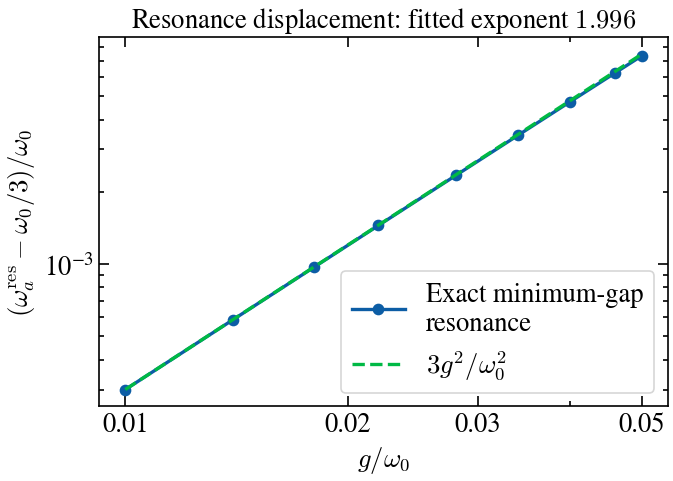

In [17]:
with plt.style.context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(5.8, 4.2))

    x = saved_scaling["g"] / omega_0
    ax.loglog(
        x,
        exact_shift / omega_0,
        marker="o",
        label="Exact minimum-gap\nresonance",
    )
    ax.loglog(
        x,
        leading_shift / omega_0,
        linestyle="--",
        label=r"$3g^2/\omega_0^2$",
    )

    ax.set_xlabel(r"$g/\omega_0$")
    apply_scaling_xticks(ax)
    ax.set_ylabel(
        r"$(\omega_a^{\mathrm{res}}-\omega_0/3)/\omega_0$"
    )
    ax.set_title(
        rf"Resonance displacement: fitted exponent ${shift_exponent:.3f}$"
    )
    ax.legend(loc="lower right",frameon=True)


    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / "N05_F4.pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        FIGURE_DIR / "N05_F4.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

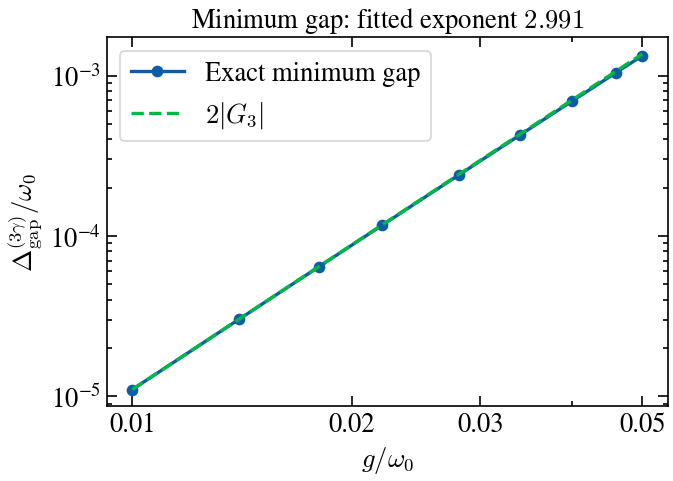

In [18]:
with plt.style.context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(5.8, 4.2))

    x = saved_scaling["g"] / omega_0
    ax.loglog(
        x,
        saved_scaling["exact_gap"] / omega_0,
        marker="o",
        label="Exact minimum gap",
    )
    ax.loglog(
        x,
        saved_scaling["analytical_gap"] / omega_0,
        linestyle="--",
        label=r"$2|G_3|$",
    )

    ax.set_xlabel(r"$g/\omega_0$")
    apply_scaling_xticks(ax)
    ax.set_ylabel(r"$\Delta_{\mathrm{gap}}^{(3\gamma)}/\omega_0$")
    ax.set_title(
        rf"Minimum gap: fitted exponent ${gap_exponent:.3f}$"
    )
    ax.legend(frameon=True)

    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / "N05_F5.pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        FIGURE_DIR / "N05_F5.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

## 14. Quantitative error diagnostics

Scaling alone does not establish quantitative accuracy. We therefore inspect:

$$
\epsilon_{\omega}
=
\frac{
|\omega_{a,\mathrm{exact}}^{\mathrm{res}}
-
\omega_{a,\delta_3=0}^{\mathrm{res}}|
}{
\omega_{a,\mathrm{exact}}^{\mathrm{res}}
},
$$

and

$$
\epsilon_{\mathrm{gap}}
=
\frac{
|\Delta_{\mathrm{gap}}^{\mathrm{exact}}-2|G_3||
}{
\Delta_{\mathrm{gap}}^{\mathrm{exact}}
}.
$$

These curves will later help define the validity range used in the main text.

In [19]:
resonance_relative_error = np.abs(
    saved_scaling["omega_a_exact_resonance"]
    - saved_scaling["omega_a_delta3_root"]
) / np.abs(saved_scaling["omega_a_exact_resonance"])

gap_relative_error = np.abs(
    saved_scaling["exact_gap"] - saved_scaling["analytical_gap"]
) / np.abs(saved_scaling["exact_gap"])

error_file = DATA_DIR / "N05_D5.csv"
np.savetxt(
    error_file,
    np.column_stack(
        [
            saved_scaling["g"],
            resonance_relative_error,
            gap_relative_error,
        ]
    ),
    delimiter=",",
    header="g,resonance_relative_error,gap_relative_error",
    comments="",
)

for g_value, resonance_error, gap_error in zip(
    saved_scaling["g"],
    resonance_relative_error,
    gap_relative_error,
):
    print(
        f"g/omega_0={g_value / omega_0:.3f} | "
        f"resonance error={resonance_error:.3e} | "
        f"gap error={gap_error:.3e}"
    )


g/omega_0=0.010 | resonance error=8.087e-07 | gap error=1.012e-03
g/omega_0=0.014 | resonance error=3.102e-06 | gap error=1.982e-03
g/omega_0=0.018 | resonance error=8.459e-06 | gap error=3.273e-03
g/omega_0=0.022 | resonance error=1.883e-05 | gap error=4.885e-03
g/omega_0=0.028 | resonance error=4.916e-05 | gap error=7.896e-03
g/omega_0=0.034 | resonance error=1.063e-04 | gap error=1.161e-02
g/omega_0=0.040 | resonance error=2.021e-04 | gap error=1.603e-02
g/omega_0=0.046 | resonance error=3.507e-04 | gap error=2.113e-02
g/omega_0=0.050 | resonance error=4.867e-04 | gap error=2.490e-02


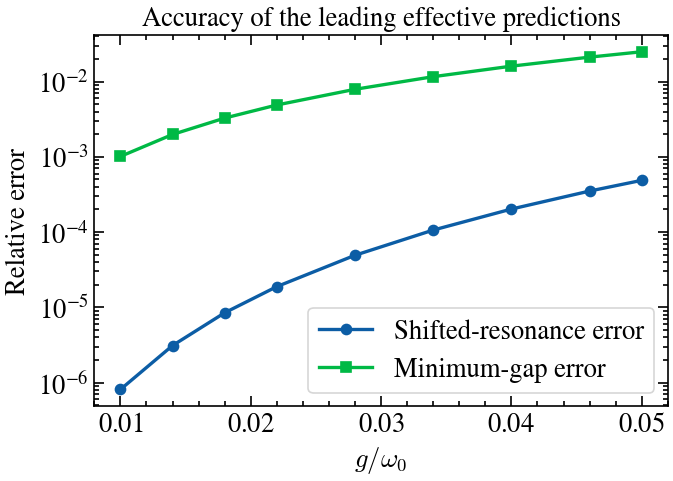

In [20]:
saved_errors = np.genfromtxt(
    error_file,
    delimiter=",",
    names=True,
)

with plt.style.context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(5.8, 4.2))

    x = saved_errors["g"] / omega_0
    ax.semilogy(
        x,
        saved_errors["resonance_relative_error"],
        marker="o",
        label="Shifted-resonance error",
    )
    ax.semilogy(
        x,
        saved_errors["gap_relative_error"],
        marker="s",
        label="Minimum-gap error",
    )

    ax.set_xlabel(r"$g/\omega_0$")
    ax.set_ylabel("Relative error")
    ax.set_title("Accuracy of the leading effective predictions")
    ax.legend(frameon=True)

    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / "N05_F6.pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        FIGURE_DIR / "N05_F6.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

## 15. Spectroscopic conclusions

The spectrum calculation establishes four points:

1. $|e,0\rangle$ and $|g,3\rangle$ lie in the same parity sector.
2. The resonance displacement is quadratic in $g$.
3. The minimum avoided-crossing gap is cubic in $g$.
4. The selected doublet and its gap are stable against oscillator-cutoff changes.

The spectral tests determine where the process occurs and how its gap
scales. The next step is to test whether the same effective Hamiltonian
reproduces the coherent dynamics and laboratory-frame observables.

## 16. Exact and effective time evolution

Direct integration of the Schrödinger equation over the slow transfer time can be unnecessarily expensive because the full Hamiltonian also contains frequencies of order $\omega_0$. Since the Hamiltonian is time independent, we instead use its exact spectral decomposition,

$$
|\psi(t)\rangle
=
\sum_j
e^{-iE_jt}
|\phi_j\rangle
\langle\phi_j|\psi(0)\rangle.
$$

This is exact within the chosen oscillator cutoff and makes long-time propagation inexpensive.

We compare three cavity frequencies:

1. the bare condition $\omega_a=\omega_0/3$;
2. the perturbative root $\delta_3=0$;
3. the exact minimum-gap resonance.

The bare initial state is $|e,0\rangle$. The central question is whether the corrected resonance restores the slow conversion predicted by the two-state Hamiltonian.

In [21]:
def spectral_evolution(
    H: qt.Qobj,
    psi0: qt.Qobj,
    tlist: np.ndarray,
    target_states: dict[str, qt.Qobj],
) -> dict[str, object]:
    """Exact closed-system evolution from a spectral decomposition."""
    eigenvalues, eigenstates = H.eigenstates()
    energies = np.asarray(eigenvalues, dtype=float)
    eigenvector_matrix = np.column_stack(
        [state.full().ravel() for state in eigenstates]
    )

    psi0_vector = psi0.full().ravel()
    expansion_coefficients = eigenvector_matrix.conj().T @ psi0_vector
    phases = np.exp(-1j * energies[:, None] * tlist[None, :])
    state_vectors = eigenvector_matrix @ (
        expansion_coefficients[:, None] * phases
    )

    probabilities = {}
    for label, target in target_states.items():
        target_vector = target.full().ravel()
        amplitudes = target_vector.conj() @ state_vectors
        probabilities[label] = np.abs(amplitudes) ** 2

    norms = np.sum(np.abs(state_vectors) ** 2, axis=0)
    return {
        "energies": energies,
        "state_vectors": state_vectors,
        "probabilities": probabilities,
        "norms": norms,
    }


def two_state_dynamics(
    delta_3: float,
    G_3: complex,
    tlist: np.ndarray,
    initial_amplitudes: np.ndarray | None = None,
) -> dict[str, np.ndarray]:
    """Propagate the canonical retained two-state Hamiltonian with QuTiP."""
    if initial_amplitudes is None:
        initial_amplitudes = np.array([1.0 + 0.0j, 0.0 + 0.0j])

    H_two = qt.Qobj(
        [
            [0.5 * delta_3, np.conjugate(G_3)],
            [G_3, -0.5 * delta_3],
        ],
        dims=[[2], [2]],
    )
    psi0_two = qt.Qobj(
        np.asarray(initial_amplitudes, dtype=complex).reshape((2, 1)),
        dims=[[2], [1]],
    ).unit()

    result = qt.sesolve(
        H_two,
        psi0_two,
        tlist,
        options={
            "method": "dop853",
            "atol": 1e-11,
            "rtol": 1e-9,
            "nsteps": 30000,
            "store_states": True,
            "progress_bar": False,
        },
    )

    amplitude_A = np.array([state[0, 0] for state in result.states], dtype=complex)
    amplitude_B = np.array([state[1, 0] for state in result.states], dtype=complex)

    return {
        "H": H_two,
        "amplitude_A": amplitude_A,
        "amplitude_B": amplitude_B,
        "population_A": np.abs(amplitude_A) ** 2,
        "population_B": np.abs(amplitude_B) ** 2,
    }

def full_target_states(N_cav: int) -> dict[str, qt.Qobj]:
    """States required for endpoint and virtual-population diagnostics."""
    return {
        "A_e0": bare_state(N_cav, 0, "e"),
        "B_g3": bare_state(N_cav, 3, "g"),
        "C_g1": bare_state(N_cav, 1, "g"),
        "D_e2": bare_state(N_cav, 2, "e"),
        "F_e4": bare_state(N_cav, 4, "e"),
        "G_g5": bare_state(N_cav, 5, "g"),
    }

In [22]:
if RUN_DYNAMICS:
    target_states = full_target_states(N_cav_reference)

    G_reference = canonical_three_photon_coupling(
        omega_a_shifted_root,
        omega_0,
        g_reference,
    )
    T_population = np.pi / abs(G_reference)
    tlist_dynamics = np.linspace(
        0.0,
        2.0 * T_population,
        dynamics_points,
    )
    normalized_time = tlist_dynamics / T_population

    resonance_choices = {
        "bare": omega_a_bare,
        "perturbative": omega_a_shifted_root,
        "exact": omega_a_exact_resonance,
    }

    exact_dynamics = {}
    effective_dynamics = {}

    # Canonical article two-state curve: the retained model evaluated at its
    # own corrected resonance, delta_3=0, while the full QRM is spectroscopically
    # calibrated to the numerical minimum-gap point.
    manuscript_effective_dynamics = two_state_dynamics(
        0.0,
        G_reference,
        tlist_dynamics,
    )

    for label, omega_a_value in resonance_choices.items():
        local_operators = build_operators(N_cav_reference)
        H_full = rabi_hamiltonian(
            omega_a_value,
            omega_0,
            g_reference,
            local_operators,
        )

        exact_dynamics[label] = spectral_evolution(
            H_full,
            target_states["A_e0"],
            tlist_dynamics,
            target_states,
        )

        effective_dynamics[label] = two_state_dynamics(
            delta_three_photon(
                omega_a_value,
                omega_0,
                g_reference,
            ),
            canonical_three_photon_coupling(
                omega_a_value,
                omega_0,
                g_reference,
            ),
            tlist_dynamics,
        )

    dynamics_file = DATA_DIR / "N05_D6.csv"
    np.savetxt(
        dynamics_file,
        np.column_stack(
            [
                normalized_time,
                exact_dynamics["bare"]["probabilities"]["B_g3"],
                exact_dynamics["perturbative"]["probabilities"]["B_g3"],
                exact_dynamics["exact"]["probabilities"]["B_g3"],
                effective_dynamics["bare"]["population_B"],
                effective_dynamics["perturbative"]["population_B"],
                effective_dynamics["exact"]["population_B"],
                manuscript_effective_dynamics["population_B"],
            ]
        ),
        delimiter=",",
        header=(
            "t_over_Tpop,"
            "exact_B_bare,exact_B_perturbative,exact_B_exact,"
            "effective_B_bare,effective_B_perturbative,effective_B_exact,"
            "effective_B_ideal_shifted"
        ),
        comments="",
    )

    print(f"Predicted population-transfer time: {T_population:.8e}")
    for label in resonance_choices:
        maximum = np.max(
            exact_dynamics[label]["probabilities"]["B_g3"]
        )
        print(f"Maximum exact P_g3 at {label:12s} resonance: {maximum:.8f}")
else:
    warnings.warn("Dynamics section skipped by RUN_DYNAMICS=False.")

Predicted population-transfer time: 7.13806766e+04
Maximum exact P_g3 at bare         resonance: 0.00059787
Maximum exact P_g3 at perturbative resonance: 0.97442548
Maximum exact P_g3 at exact        resonance: 0.99557194


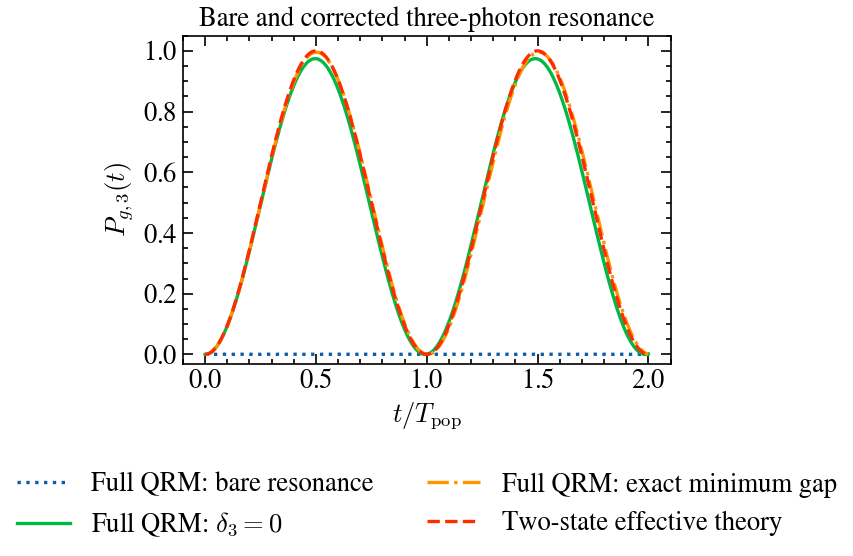

In [23]:
if RUN_DYNAMICS:
    saved_dynamics = np.genfromtxt(
        dynamics_file,
        delimiter=",",
        names=True,
    )

    with plt.style.context(PLOT_STYLE):
        fig, ax = plt.subplots(figsize=(6.4, 5.2))

        ax.plot(
            saved_dynamics["t_over_Tpop"],
            saved_dynamics["exact_B_bare"],
            linestyle=":",
            label="Full QRM: bare resonance",
        )
        ax.plot(
            saved_dynamics["t_over_Tpop"],
            saved_dynamics["exact_B_perturbative"],
            label=r"Full QRM: $\delta_3=0$",
        )
        ax.plot(
            saved_dynamics["t_over_Tpop"],
            saved_dynamics["exact_B_exact"],
            linestyle="-.",
            label="Full QRM: exact minimum gap",
        )
        ax.plot(
            saved_dynamics["t_over_Tpop"],
            saved_dynamics["effective_B_perturbative"],
            linestyle="--",
            label="Two-state effective theory",
        )

        ax.set_xlabel(r"$t/T_{\mathrm{pop}}$")
        ax.set_ylabel(r"$P_{g,3}(t)$")
        ax.set_ylim(-0.03, 1.05)
        ax.set_title("Bare and corrected three-photon resonance")
        ax.legend(
            frameon=False,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.30),
            ncol=2,
            borderaxespad=0.0,
        )

        fig.tight_layout()
        fig.savefig(
            FIGURE_DIR / "N05_F7.pdf",
            bbox_inches="tight",
        )
        fig.savefig(
            FIGURE_DIR / "N05_F7.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

The bare resonance leaves a residual detuning of order $g^2$, while the desired endpoint coupling is only of order $g^3$. The maximum transfer predicted by the two-state model is

$$
P_{B,\max}^{\mathrm{eff}}
=
\frac{4|G_3|^2}{\delta_3^2+4|G_3|^2}.
$$

At the bare condition, $|\delta_3/G_3|$ grows as $1/g$ in the weak-coupling limit, so the nominal energy matching becomes progressively worse relative to the shrinking cubic gap. The corrected resonance is therefore not a small cosmetic improvement: it is necessary to enter the resonant window.

## 17. Reconstruction and virtual populations

A clean comparison between the slow effective theory and the full Hamiltonian should distinguish two preparations:

1. **Bare preparation:** the laboratory starts in $|e,0\rangle$. This state contains a fast component relative to the dressed slow manifold and produces initial slip and micromotion.
2. **Dressed preparation:** the laboratory starts in the reconstructed state $|A\rangle_{\mathrm{rec}}$. This isolates the slow manifold more cleanly.

The code below constructs the leading reconstructed basis explicitly. The perturbative vectors are orthonormalized numerically. This changes them only beyond the displayed order and prevents small normalization artifacts from obscuring the comparison.

In [24]:
def reconstructed_basis_states(
    N_cav: int,
    omega_a: float,
    omega_0: float,
    g: float,
) -> dict[str, qt.Qobj | float]:
    """Construct leading reconstructed endpoint states and orthonormalize them."""
    Delta = omega_0 - omega_a
    Sigma = omega_0 + omega_a

    A = bare_state(N_cav, 0, "e")
    B = bare_state(N_cav, 3, "g")
    C = bare_state(N_cav, 1, "g")
    D = bare_state(N_cav, 2, "e")
    F = bare_state(N_cav, 4, "e")
    G = bare_state(N_cav, 5, "g")

    A_raw = (
        A
        + (g / Delta) * C
        - (np.sqrt(2.0) * g**2 / (2.0 * omega_a * Delta)) * D
    )

    B_raw = (
        B
        - (np.sqrt(3.0) * g / Delta) * D
        - (2.0 * g / Sigma) * F
        - (np.sqrt(6.0) * g**2 / (2.0 * omega_a * Delta)) * C
        + (np.sqrt(5.0) * g**2 / (omega_a * Sigma)) * G
    )

    A_rec = A_raw.unit()
    raw_overlap = A_rec.overlap(B_raw)
    B_orthogonal = B_raw - raw_overlap * A_rec
    B_rec = B_orthogonal.unit()

    return {
        "A_rec": A_rec,
        "B_rec": B_rec,
        "raw_overlap": abs(raw_overlap),
        "Delta": Delta,
        "Sigma": Sigma,
    }


def reconstructed_state_vectors(
    amplitude_A: np.ndarray,
    amplitude_B: np.ndarray,
    A_rec: qt.Qobj,
    B_rec: qt.Qobj,
) -> np.ndarray:
    """Map retained amplitudes to normalized laboratory-frame vectors."""
    A_vector = A_rec.full().ravel()
    B_vector = B_rec.full().ravel()
    states = (
        A_vector[:, None] * amplitude_A[None, :]
        + B_vector[:, None] * amplitude_B[None, :]
    )
    norms = np.sqrt(np.sum(np.abs(states) ** 2, axis=0))
    return states / norms[None, :]

In [25]:
if RUN_DYNAMICS:
    reconstruction = reconstructed_basis_states(
        N_cav_reference,
        omega_a_exact_resonance,
        omega_0,
        g_reference,
    )
    A_rec = reconstruction["A_rec"]
    B_rec = reconstruction["B_rec"]

    operators_exact = build_operators(N_cav_reference)
    H_exact_resonance = rabi_hamiltonian(
        omega_a_exact_resonance,
        omega_0,
        g_reference,
        operators_exact,
    )

    exact_dressed = spectral_evolution(
        H_exact_resonance,
        A_rec,
        tlist_dynamics,
        target_states,
    )

    effective_exact = two_state_dynamics(
        delta_three_photon(
            omega_a_exact_resonance,
            omega_0,
            g_reference,
        ),
        canonical_three_photon_coupling(
            omega_a_exact_resonance,
            omega_0,
            g_reference,
        ),
        tlist_dynamics,
    )

    reconstructed_vectors = reconstructed_state_vectors(
        effective_exact["amplitude_A"],
        effective_exact["amplitude_B"],
        A_rec,
        B_rec,
    )

    reconstructed_probabilities = {}
    for label, target in target_states.items():
        target_vector = target.full().ravel()
        amplitudes = target_vector.conj() @ reconstructed_vectors
        reconstructed_probabilities[label] = np.abs(amplitudes) ** 2

    exact_vectors = exact_dressed["state_vectors"]
    fidelities = np.abs(
        np.sum(exact_vectors.conj() * reconstructed_vectors, axis=0)
    ) ** 2

    reconstruction_file = DATA_DIR / "N05_D7.csv"
    np.savetxt(
        reconstruction_file,
        np.column_stack(
            [
                normalized_time,
                exact_dressed["probabilities"]["A_e0"],
                exact_dressed["probabilities"]["B_g3"],
                reconstructed_probabilities["A_e0"],
                reconstructed_probabilities["B_g3"],
                exact_dressed["probabilities"]["C_g1"],
                exact_dressed["probabilities"]["D_e2"],
                exact_dressed["probabilities"]["F_e4"],
                exact_dressed["probabilities"]["G_g5"],
                reconstructed_probabilities["C_g1"],
                reconstructed_probabilities["D_e2"],
                reconstructed_probabilities["F_e4"],
                reconstructed_probabilities["G_g5"],
                fidelities,
            ]
        ),
        delimiter=",",
        header=(
            "t_over_Tpop,"
            "exact_A,exact_B,reconstructed_A,reconstructed_B,"
            "exact_C,exact_D,exact_F,exact_G,"
            "reconstructed_C,reconstructed_D,reconstructed_F,reconstructed_G,"
            "state_fidelity"
        ),
        comments="",
    )

    print(f"Raw reconstructed-basis overlap: {reconstruction['raw_overlap']:.3e}")
    print(f"Minimum reconstructed-state fidelity: {np.min(fidelities):.8f}")

Raw reconstructed-basis overlap: 0.000e+00
Minimum reconstructed-state fidelity: 0.97417912


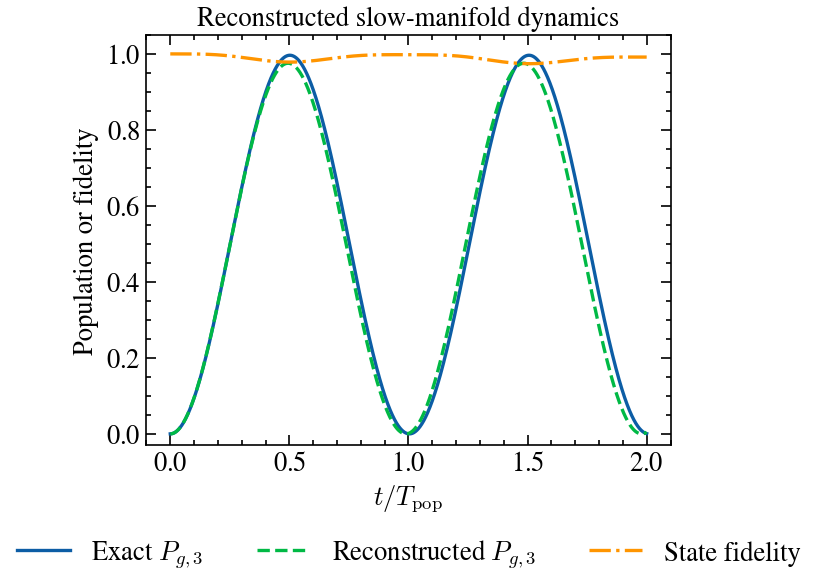

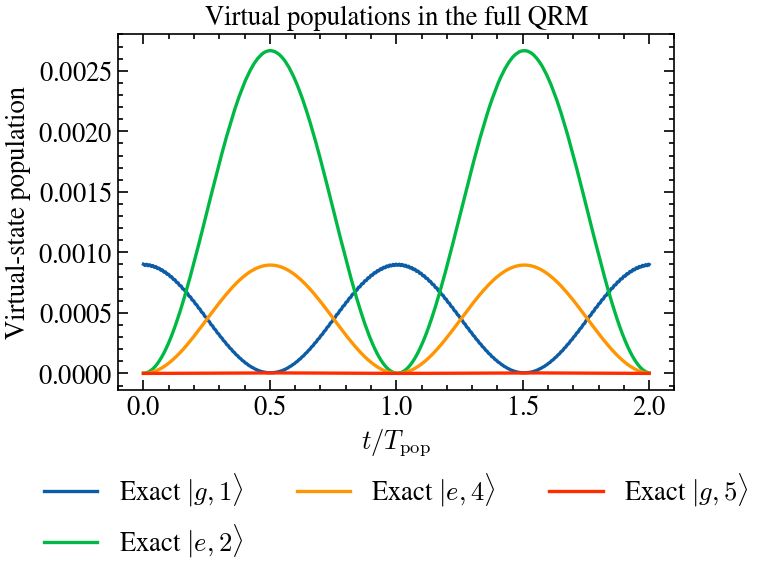

In [26]:
if RUN_DYNAMICS:
    saved_reconstruction = np.genfromtxt(
        reconstruction_file,
        delimiter=",",
        names=True,
    )

    with plt.style.context(PLOT_STYLE):
        fig, ax = plt.subplots(figsize=(6.4, 5.2))

        ax.plot(
            saved_reconstruction["t_over_Tpop"],
            saved_reconstruction["exact_B"],
            label=r"Exact $P_{g,3}$",
        )
        ax.plot(
            saved_reconstruction["t_over_Tpop"],
            saved_reconstruction["reconstructed_B"],
            linestyle="--",
            label=r"Reconstructed $P_{g,3}$",
        )
        ax.plot(
            saved_reconstruction["t_over_Tpop"],
            saved_reconstruction["state_fidelity"],
            linestyle="-.",
            label="State fidelity",
        )

        ax.set_xlabel(r"$t/T_{\mathrm{pop}}$")
        ax.set_ylabel("Population or fidelity")
        ax.set_ylim(-0.03, 1.05)
        ax.set_title("Reconstructed slow-manifold dynamics")
        ax.legend(
            frameon=False,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.20),
            ncol=3,
            borderaxespad=0.0,
        )


        fig.tight_layout()
        fig.savefig(
            FIGURE_DIR / "N05_F8.pdf",
            bbox_inches="tight",
        )
        fig.savefig(
            FIGURE_DIR / "N05_F8.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

    with plt.style.context(PLOT_STYLE):
        fig, ax = plt.subplots(figsize=(6.4, 5.2))

        for label, display in [
            ("exact_C", r"Exact $|g,1\rangle$"),
            ("exact_D", r"Exact $|e,2\rangle$"),
            ("exact_F", r"Exact $|e,4\rangle$"),
            ("exact_G", r"Exact $|g,5\rangle$"),
        ]:
            ax.plot(
                saved_reconstruction["t_over_Tpop"],
                saved_reconstruction[label],
                label=display,
            )

        ax.set_xlabel(r"$t/T_{\mathrm{pop}}$")
        ax.set_ylabel("Virtual-state population")
        ax.set_title("Virtual populations in the full QRM")
        ax.legend(frameon=False,loc="upper center",bbox_to_anchor=(0.5, -0.20),ncol=3,borderaxespad=0.0,
        )


        fig.tight_layout()
        fig.savefig(
            FIGURE_DIR / "N05_F9.pdf",
            bbox_inches="tight",
        )
        fig.savefig(
            FIGURE_DIR / "N05_F9.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

## 18. Long-time accumulation of effective-model errors

Agreement over one transfer period does not determine the useful time
horizon of an effective model. A small frequency error produces a phase
drift that can accumulate over many cycles.

For the exact state and the reconstructed effective state, define

$$
\epsilon_F(t)
=
1-
\left|
\langle\psi_{\mathrm{full}}(t)|
\psi_{\mathrm{rec}}(t)\rangle
\right|^2,
$$

and the target-population error

$$
\epsilon_B(t)
=
\left|
P_{g,3}^{\mathrm{full}}(t)
-
P_{g,3}^{\mathrm{rec}}(t)
\right|.
$$

The running maximum

$$
\epsilon_F^{\max}(T)
=
\max_{0\leq t\leq T}\epsilon_F(t)
$$

records whether the approximation has already departed significantly,
even if the instantaneous error later becomes small again.

If the exact and effective oscillation frequencies differ by
$\delta\Omega_3$, the phase drift grows as

$$
\Delta\phi(t)=\delta\Omega_3 t.
$$

Since $G_3=O(g^3)$ and the first omitted correction to the coupling is
expected at $O(g^5)$, the relative frequency error is expected to scale
as $O(g^2)$. The accumulated error over a fixed number of transfer
periods should therefore increase as the coupling grows.

In [27]:
LONG_TIME_PERIODS = 10.0
long_time_points = 10001 if DENSE_SCAN else 5001
long_time_couplings = omega_0 * np.array([0.015, 0.020, 0.030, 0.040])

long_time_results = {}
long_time_summary_rows = []

if RUN_DYNAMICS:
    for g_value in long_time_couplings:
        # Determine the resonance and gap at this same coupling.  Using the
        # nearest row of the separate scaling grid silently mixes different
        # couplings whenever g_value is not itself one of that grid's nodes.
        omega_shifted_local = shifted_resonance_root(omega_0, g_value)
        minimization_local = minimize_scalar(
            exact_three_photon_gap,
            bounds=(
                omega_shifted_local - 0.0015 * omega_0,
                omega_shifted_local + 0.0015 * omega_0,
            ),
            args=(omega_0, g_value, N_cav_reference),
            method="bounded",
            options={"xatol": 1e-12},
        )
        if not minimization_local.success:
            raise RuntimeError(
                f"Long-time resonance minimization failed at g={g_value:.6g}."
            )

        omega_exact = float(minimization_local.x)
        exact_gap = float(minimization_local.fun)
        G_effective = canonical_three_photon_coupling(
            omega_exact,
            omega_0,
            g_value,
        )
        delta_effective = delta_three_photon(
            omega_exact,
            omega_0,
            g_value,
        )
        effective_frequency = np.sqrt(
            delta_effective**2 + 4.0 * abs(G_effective) ** 2
        )

        T_effective = np.pi / abs(G_effective)
        t_long = np.linspace(
            0.0,
            LONG_TIME_PERIODS * T_effective,
            long_time_points,
        )
        periods_long = t_long / T_effective

        local_targets = full_target_states(N_cav_reference)
        local_reconstruction = reconstructed_basis_states(
            N_cav_reference,
            omega_exact,
            omega_0,
            g_value,
        )
        A_rec_local = local_reconstruction["A_rec"]
        B_rec_local = local_reconstruction["B_rec"]

        local_operators = build_operators(N_cav_reference)
        H_full = rabi_hamiltonian(
            omega_exact,
            omega_0,
            g_value,
            local_operators,
        )
        exact_long = spectral_evolution(
            H_full,
            A_rec_local,
            t_long,
            local_targets,
        )

        effective_long = two_state_dynamics(
            delta_effective,
            G_effective,
            t_long,
        )
        reconstructed_long = reconstructed_state_vectors(
            effective_long["amplitude_A"],
            effective_long["amplitude_B"],
            A_rec_local,
            B_rec_local,
        )

        calibrated_long = two_state_dynamics(
            0.0,
            -0.5 * exact_gap,
            t_long,
        )
        reconstructed_calibrated = reconstructed_state_vectors(
            calibrated_long["amplitude_A"],
            calibrated_long["amplitude_B"],
            A_rec_local,
            B_rec_local,
        )

        exact_vectors = exact_long["state_vectors"]
        fidelity = np.abs(
            np.sum(exact_vectors.conj() * reconstructed_long, axis=0)
        ) ** 2
        fidelity_calibrated = np.abs(
            np.sum(
                exact_vectors.conj() * reconstructed_calibrated,
                axis=0,
            )
        ) ** 2

        B_vector = local_targets["B_g3"].full().ravel()
        reconstructed_B = np.abs(
            B_vector.conj() @ reconstructed_long
        ) ** 2
        exact_B = exact_long["probabilities"]["B_g3"]

        infidelity = 1.0 - fidelity
        infidelity_calibrated = 1.0 - fidelity_calibrated
        population_error = np.abs(exact_B - reconstructed_B)
        running_infidelity = np.maximum.accumulate(infidelity)
        running_population_error = np.maximum.accumulate(population_error)

        phase_drift = (exact_gap - effective_frequency) * t_long

        long_time_results[float(g_value)] = {
            "periods": periods_long,
            "infidelity": infidelity,
            "infidelity_calibrated": infidelity_calibrated,
            "population_error": population_error,
            "running_infidelity": running_infidelity,
            "running_population_error": running_population_error,
            "phase_drift": phase_drift,
            "exact_gap": exact_gap,
            "effective_frequency": effective_frequency,
        }

        for period_sample in [1.0, 2.0, 5.0, 10.0]:
            sampled_infidelity = np.interp(
                period_sample,
                periods_long,
                running_infidelity,
            )
            sampled_population_error = np.interp(
                period_sample,
                periods_long,
                running_population_error,
            )
            long_time_summary_rows.append(
                [
                    g_value,
                    period_sample,
                    sampled_infidelity,
                    sampled_population_error,
                    exact_gap,
                    effective_frequency,
                ]
            )

    long_time_summary_file = (
        DATA_DIR / "N05_D8.csv"
    )
    np.savetxt(
        long_time_summary_file,
        np.asarray(long_time_summary_rows),
        delimiter=",",
        header=(
            "g,periods,running_infidelity,running_population_error,"
            "exact_gap,effective_frequency"
        ),
        comments="",
    )

    reference_long = long_time_results[float(0.020 * omega_0)]
    long_time_reference_file = (
        DATA_DIR / "N05_D9.csv"
    )
    np.savetxt(
        long_time_reference_file,
        np.column_stack(
            [
                reference_long["periods"],
                reference_long["infidelity"],
                reference_long["infidelity_calibrated"],
                reference_long["population_error"],
                reference_long["running_infidelity"],
                reference_long["phase_drift"],
            ]
        ),
        delimiter=",",
        header=(
            "t_over_Tpop,infidelity,infidelity_spectrally_calibrated,"
            "target_population_error,running_infidelity,phase_drift"
        ),
        comments="",
    )

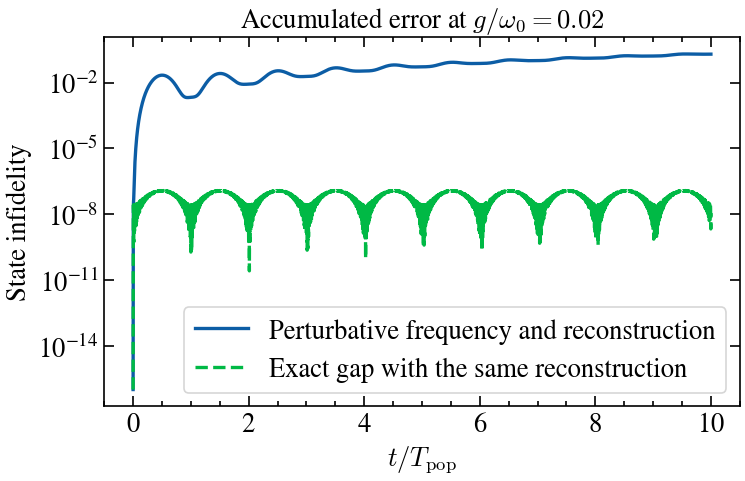

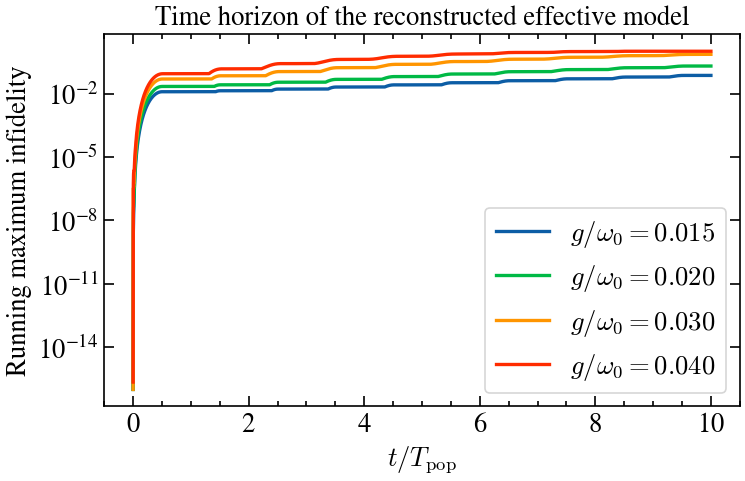

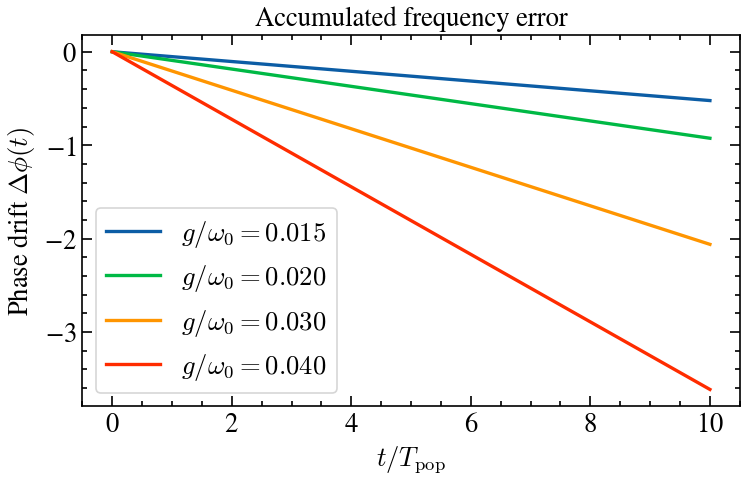

In [28]:
if RUN_DYNAMICS:
    reference_long = long_time_results[float(0.020 * omega_0)]

    with plt.style.context(PLOT_STYLE):
        fig, ax = plt.subplots(figsize=(6.4, 4.2))

        ax.semilogy(
            reference_long["periods"],
            np.maximum(reference_long["infidelity"], 1e-16),
            label="Perturbative frequency and reconstruction",
        )
        ax.semilogy(
            reference_long["periods"],
            np.maximum(
                reference_long["infidelity_calibrated"],
                1e-16,
            ),
            linestyle="--",
            label="Exact gap with the same reconstruction",
        )

        ax.set_xlabel(r"$t/T_{\mathrm{pop}}$")
        ax.set_ylabel("State infidelity")
        ax.set_title(
            r"Accumulated error at $g/\omega_0=0.02$"
        )
        ax.legend(frameon=True)
        
        fig.tight_layout()
        fig.savefig(
            FIGURE_DIR / "N05_F10.pdf",
            bbox_inches="tight",
        )
        fig.savefig(
            FIGURE_DIR / "N05_F10.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

    with plt.style.context(PLOT_STYLE):
        fig, ax = plt.subplots(figsize=(6.4, 4.2))

        for g_value, result in long_time_results.items():
            ax.semilogy(
                result["periods"],
                np.maximum(result["running_infidelity"], 1e-16),
                label=rf"$g/\omega_0={g_value / omega_0:.3f}$",
            )

        ax.set_xlabel(r"$t/T_{\mathrm{pop}}$")
        ax.set_ylabel("Running maximum infidelity")
        ax.set_title("Time horizon of the reconstructed effective model")
        ax.legend(frameon=True)

        fig.tight_layout()
        fig.savefig(
            FIGURE_DIR / "N05_F11.pdf",
            bbox_inches="tight",
        )
        fig.savefig(
            FIGURE_DIR / "N05_F11.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

    with plt.style.context(PLOT_STYLE):
        fig, ax = plt.subplots(figsize=(6.4, 4.2))

        for g_value, result in long_time_results.items():
            ax.plot(
                result["periods"],
                result["phase_drift"],
                label=rf"$g/\omega_0={g_value / omega_0:.3f}$",
            )

        ax.set_xlabel(r"$t/T_{\mathrm{pop}}$")
        ax.set_ylabel(r"Phase drift $\Delta\phi(t)$")
        ax.set_title("Accumulated frequency error")
        ax.legend(frameon=True)
    

        fig.tight_layout()
        fig.savefig(
            FIGURE_DIR / "N05_F12.pdf",
            bbox_inches="tight",
        )
        fig.savefig(
            FIGURE_DIR / "N05_F12.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

## 19. Bare preparation, dressed preparation, and initial slip

A bare endpoint state and its reconstructed dressed counterpart have the
same slow retained amplitude but different fast-sector content. Starting
from $|e,0\rangle$, the virtual dressing must form dynamically and
produces a short initial transient. Starting from
$|A\rangle_{\mathrm{rec}}$ places the system closer to the slow manifold.

The fast timescale is set by the off-resonant denominators. For the
reference point, a representative period is

$$
T_{\mathrm{fast}}
=
\frac{2\pi}{|\Delta|}.
$$

The comparison below tracks the summed population of the leading virtual
states during the first ten fast periods.

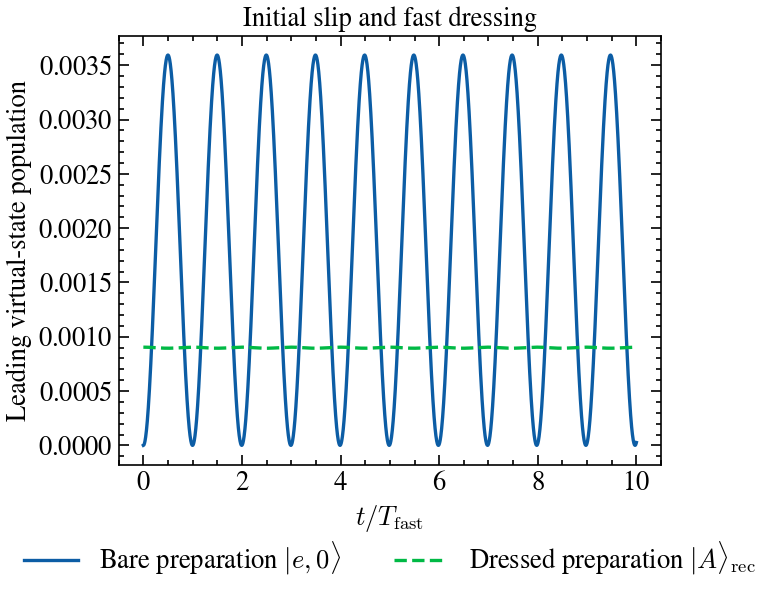

In [29]:
if RUN_DYNAMICS:
    Delta_exact = omega_0 - omega_a_exact_resonance
    T_fast = 2.0 * np.pi / abs(Delta_exact)
    t_fast = np.linspace(0.0, 10.0 * T_fast, 3001)

    exact_from_bare = spectral_evolution(
        H_exact_resonance,
        target_states["A_e0"],
        t_fast,
        target_states,
    )
    exact_from_dressed = spectral_evolution(
        H_exact_resonance,
        A_rec,
        t_fast,
        target_states,
    )

    virtual_labels = ["C_g1", "D_e2", "F_e4", "G_g5"]
    virtual_bare = np.sum(
        [
            exact_from_bare["probabilities"][label]
            for label in virtual_labels
        ],
        axis=0,
    )
    virtual_dressed = np.sum(
        [
            exact_from_dressed["probabilities"][label]
            for label in virtual_labels
        ],
        axis=0,
    )

    initial_slip_file = DATA_DIR / "N05_D10.csv"
    np.savetxt(
        initial_slip_file,
        np.column_stack(
            [
                t_fast / T_fast,
                virtual_bare,
                virtual_dressed,
                exact_from_bare["probabilities"]["A_e0"],
                exact_from_dressed["probabilities"]["A_e0"],
            ]
        ),
        delimiter=",",
        header=(
            "t_over_Tfast,virtual_population_bare,"
            "virtual_population_dressed,A_population_bare,"
            "A_population_dressed"
        ),
        comments="",
    )

    with plt.style.context(PLOT_STYLE):
        fig, ax = plt.subplots(figsize=(6.4, 5.2))

        ax.plot(
            t_fast / T_fast,
            virtual_bare,
            label=r"Bare preparation $|e,0\rangle$",
        )
        ax.plot(
            t_fast / T_fast,
            virtual_dressed,
            linestyle="--",
            label=r"Dressed preparation $|A\rangle_{\mathrm{rec}}$",
        )

        ax.set_xlabel(r"$t/T_{\mathrm{fast}}$")
        ax.set_ylabel("Leading virtual-state population")
        ax.set_title("Initial slip and fast dressing")
        ax.legend(
            frameon=False,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.15),
            ncol=2,
            borderaxespad=0.0,
        )
        

        fig.tight_layout()
        fig.savefig(
            FIGURE_DIR / "N05_F13.pdf",
            bbox_inches="tight",
        )
        fig.savefig(
            FIGURE_DIR / "N05_F13.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()


## 20. Complementary physical views of the different methods

The methods agree on the physical invariants after their retained-space phases, gauges, and controlled orders are aligned, but they do not illuminate the same aspect of the process.

| Method | Main physical question answered |
|---|---|
| Projection/resolvent | Which virtual states and denominators carry the process? |
| Schrieffer--Wolff | How are retained states, observables, and jump operators dressed? |
| Small rotations | Which nonlinear operators are generated algebraically? |
| Magnus | Which frequency combinations accumulate coherently in time? |
| James--Jerke | Which processes are resolved as slow by a finite temporal filter? |
| Adiabatic elimination | How does the fast sector follow the slow endpoint amplitudes? |
| Floquet--Sambe | How is the resonance represented or engineered in frequency space? |

Using more than one method supplies a richer picture:

- **Projection plus SW** connects virtual pathways to laboratory-frame dressing.
- **MSR plus Magnus** connects algebraic operator generation to phase-matched accumulation.
- **Magnus plus James--Jerke** separates mathematical slow accumulation from experimentally resolved slow dynamics.
- **Projection plus adiabatic elimination** connects a spectral resolvent to dynamical slaving and initial slip.
- **Static methods plus Floquet theory** distinguish an intrinsic virtual interaction from an externally engineered realization.

Agreement among these differently organized methods is supporting evidence, but it does not replace comparison with the converged full Rabi model.

### 20.1 Projection and resolvent

Choose
$$
P=|e,0\rangle\langle e,0|+|g,3\rangle\langle g,3|.
$$
The Bloch--Horowitz self-energy generates the second-order diagonal shifts and
the third-order path through $|g,1\rangle$ and $|e,2\rangle$. This route makes
the virtual connectivity, energy denominators, model-space metric, and
reconstruction wave operator explicit.

### 20.2 Schrieffer--Wolff block diagonalization

A block-off-diagonal generator removes the $P$-$Q$ couplings order by order
without eliminating the resonant $|e,0\rangle\leftrightarrow|g,3\rangle$ block
itself. Nested commutators produce the cubic retained-space term, while the inverse
transformation supplies the dressing needed to reconstruct laboratory states and
observables.

### 20.3 Method of small rotations

Sequential near-identity rotations eliminate the nonresonant one-photon ladders.
Their commutator algebra generates the same second-order diagonal dressing and
third-order resonant operator. This route is especially transparent when the
operator algebra closes, but operator-valued denominators, normalization, and the
inverse rotations must be tracked consistently.

### 20.4 Magnus and James--Jerke temporal averaging

In the interaction picture the Rabi coupling contains harmonics at
$\pm\Delta$ and $\pm\Sigma$. A third-order time-ordered product can combine
$$
\sigma_-a^\dagger,\qquad
\sigma_+a^\dagger,\qquad
\sigma_-a^\dagger
$$
into a slowly accumulating cubic vertex near
$\omega_0\simeq3\omega_a$. The second-order diagonal terms belong in the same
resonance condition. Magnus boundary terms and James--Jerke finite-bandwidth
filtering also clarify why a slow generator is not, by itself, a complete
continuous-time prediction.

### 20.5 Recursive adiabatic elimination

Solving the intermediate amplitudes $c_{g1}$ and $c_{e2}$ in terms of the
retained amplitudes reproduces the same virtual-path product. The procedure is
physically transparent, but derivative corrections, normalization, and initial
slip become important because the desired transfer time scales as $g^{-3}$.

### 20.6 Floquet--Sambe representation

The static interaction-picture problem can already be represented in an extended
frequency space. Longitudinal modulation adds physical sidebands and can relocate
or enhance the resonance, but the complete endpoint process still contains three
elementary vertices. Floquet engineering changes the denominators and vertex
weights; it does not turn the cubic endpoint coupling into a first-order process.

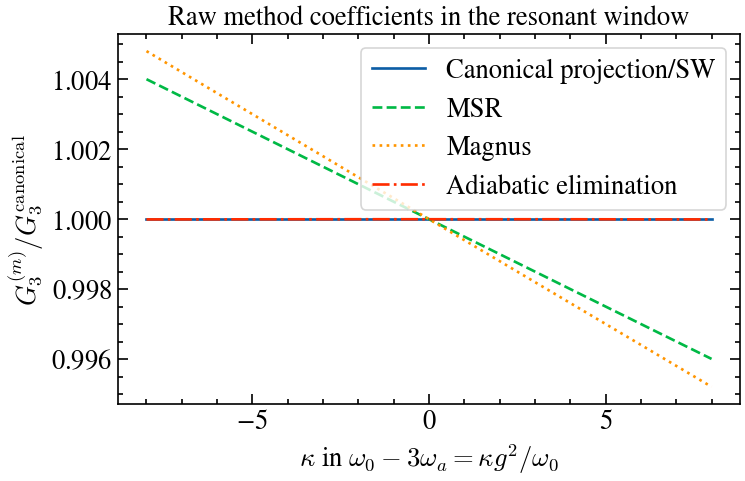

In [30]:
def G_canonical(omega_a: float, omega_0: float, g: float) -> float:
    Delta = omega_0 - omega_a
    return -np.sqrt(6.0) * g**3 / (2.0 * omega_a * Delta)


def G_msr_raw(omega_a: float, omega_0: float, g: float) -> float:
    Delta = omega_0 - omega_a
    Sigma = omega_0 + omega_a
    return -4.0 * np.sqrt(6.0) * g**3 * omega_0 / (
        3.0 * Delta**2 * Sigma
    )


def G_magnus_raw(omega_a: float, omega_0: float, g: float) -> float:
    Delta = omega_0 - omega_a
    return -np.sqrt(6.0) * g**3 / Delta**2


def G_ae_raw(omega_a: float, omega_0: float, g: float) -> float:
    Sigma = omega_0 + omega_a
    Lambda = 0.5 * Sigma
    return -np.sqrt(6.0) * g**3 / Lambda**2


kappa_values = np.linspace(-8.0, 8.0, 161)
detuning_values = kappa_values * g_reference**2 / omega_0
omega_values = (omega_0 - detuning_values) / 3.0

method_coefficients = {
    "Canonical projection/SW": np.array(
        [G_canonical(w, omega_0, g_reference) for w in omega_values]
    ),
    "MSR": np.array(
        [G_msr_raw(w, omega_0, g_reference) for w in omega_values]
    ),
    "Magnus": np.array(
        [G_magnus_raw(w, omega_0, g_reference) for w in omega_values]
    ),
    "Adiabatic elimination": np.array(
        [G_ae_raw(w, omega_0, g_reference) for w in omega_values]
    ),
}

alignment_file = DATA_DIR / "N05_D11.csv"
np.savetxt(
    alignment_file,
    np.column_stack(
        [
            kappa_values,
            omega_values,
            method_coefficients["Canonical projection/SW"],
            method_coefficients["MSR"],
            method_coefficients["Magnus"],
            method_coefficients["Adiabatic elimination"],
        ]
    ),
    delimiter=",",
    header="kappa,omega_a,G_canonical,G_msr,G_magnus,G_ae",
    comments="",
)

with plt.style.context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(6.4, 4.2))

    reference = method_coefficients["Canonical projection/SW"]

    # Different visual style for each curve
    line_styles = cycle([
        "-",
        "--",
        ":",
        "-.",    
    ])
    for label, values in method_coefficients.items():
        ax.plot(
            kappa_values,
            values / reference,
            label=label,
            linestyle=next(line_styles),
            markevery=20,
            markersize=4.5,
            linewidth=1.6,
        )

    ax.set_xlabel(
        r"$\kappa$ in $\omega_0-3\omega_a=\kappa g^2/\omega_0$"
    )
    ax.set_ylabel(
        r"$G_3^{(m)}/G_3^{\mathrm{canonical}}$"
    )
    ax.set_title(
        "Raw method coefficients in the resonant window"
    )

    ax.legend(frameon=True)

    fig.tight_layout()

    fig.savefig(
        FIGURE_DIR / "N05_F14.pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        FIGURE_DIR / "N05_F14.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


## 21. Effective reductions for control design and error mitigation

The reduction identifies not only the desired interaction but also the
corrections that must be controlled.

| Method | Control or error-mitigation information |
|---|---|
| Projection/resolvent | Leakage paths, self-energy shifts, and interfering virtual pathways |
| Schrieffer--Wolff | Dressed controls, observables, and noise operators |
| Small rotations | Unwanted operators generated with the target term and possible counterterms |
| Magnus | Pulse symmetries that cancel selected orders and endpoint kick corrections |
| James--Jerke | The temporal bandwidth required to retain the slow process and reject carriers |
| Adiabatic elimination | Ramp shaping, slow-manifold preparation, and initial-slip compensation |
| Floquet--Sambe | Sideband placement, Bessel-weight control, and avoidance of competing quasienergy resonances |

For the static three-photon process, the first control action is the
resonance correction

$$
\omega_a
=
\frac{\omega_0}{3}
+
\frac{3g^2}{\omega_0}
+
O(g^4).
$$

The dynamics figure above shows that this calibration changes the
target transfer from almost completely suppressed to nearly resonant.

A second control action is preparation in the reconstructed dressed
basis. This reduces the fast transient associated with the formation of
the virtual dressing cloud.

In a modulation-assisted realization, the effective endpoint strength
is proportional to

$$
J_{-1}(x)J_0^2(x),
\qquad
x=\frac{A}{\omega_f},
$$

rather than to a single sideband coefficient. The modulation amplitude
can therefore enhance the target pathway, place it near a maximum, or
suppress it near a Bessel zero. Competing sidebands and their
denominators must be checked at the same time.

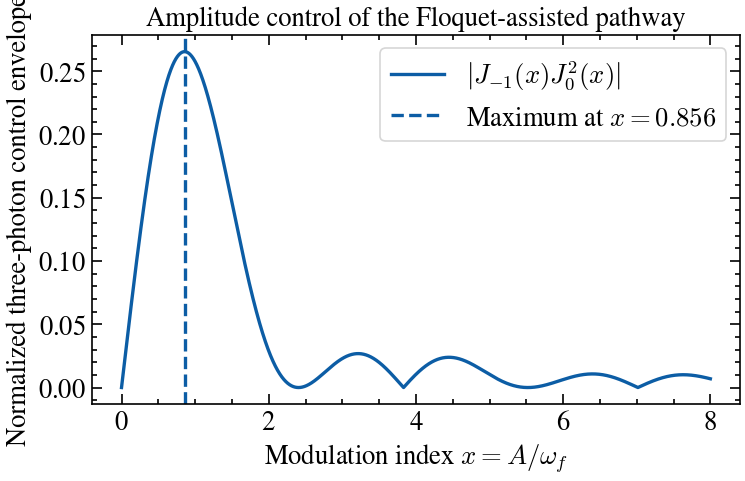

Optimal modulation index in the scanned interval: 0.856000
Maximum normalized envelope: 0.265452
J_0(x_opt)  = 0.825036
J_-1(x_opt) = -0.389977


In [31]:
x_control = np.linspace(0.0, 8.0, 4001)
J0_control = jv(0, x_control)
Jm1_control = jv(-1, x_control)
target_control_envelope = np.abs(
    Jm1_control * J0_control**2
)

optimum_index = int(np.argmax(target_control_envelope))
x_optimum = float(x_control[optimum_index])
optimum_envelope = float(target_control_envelope[optimum_index])

with plt.style.context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(6.4, 4.2))

    ax.plot(
        x_control,
        target_control_envelope,
        label=r"$|J_{-1}(x)J_0^2(x)|$",
    )
    ax.axvline(
        x_optimum,
        linestyle="--",
        label=rf"Maximum at $x={x_optimum:.3f}$",
    )

    ax.set_xlabel(r"Modulation index $x=A/\omega_f$")
    ax.set_ylabel("Normalized three-photon control envelope")
    ax.set_title("Amplitude control of the Floquet-assisted pathway")
    ax.legend(frameon=True)
   
    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / "N05_F15.pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        FIGURE_DIR / "N05_F15.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

print(f"Optimal modulation index in the scanned interval: {x_optimum:.6f}")
print(f"Maximum normalized envelope: {optimum_envelope:.6f}")
print(f"J_0(x_opt)  = {jv(0, x_optimum):.6f}")
print(f"J_-1(x_opt) = {jv(-1, x_optimum):.6f}")

## 22. Static Floquet--Sambe and modulation-assisted resonance

### 22.1 Static frequency-space representation

At the leading crossing,

$$
\omega_0=3\omega_a,
\qquad
\Delta=2\omega_a,
\qquad
\Sigma=4\omega_a.
$$

The interaction-picture Hamiltonian is periodic with fundamental frequency

$$
\nu=2\omega_a.
$$

The static virtual pathway can be represented in Sambe space as

$$
|A,0\rangle_{\mathrm S}
\rightarrow
|C,1\rangle_{\mathrm S}
\rightarrow
|D,-1\rangle_{\mathrm S}
\rightarrow
|B,0\rangle_{\mathrm S}.
$$

The two intermediate quasienergies are $-\nu$ and $+\nu$. Their denominator product is negative, giving

$$
G_3^{\mathrm{S,stat}}
=
\frac{g(\sqrt{2}g)(\sqrt{3}g)}
{[0-(-\nu)][0-(+\nu)]}
=
-\frac{\sqrt{6}g^3}{\nu^2}
=
-\frac{\sqrt{6}g^3}{4\omega_a^2}.
$$

These Fourier labels describe an undriven interaction-picture representation. They are not physical drive photons.

### 22.2 Longitudinal modulation

For

$$
\hat H_{\mathrm d}(t)
=
\Omega_c\hat n
+
\frac{\Omega_0+A\cos(\omega_ft)}{2}\hat\sigma_z
+
\lambda(\hat a+\hat a^\dagger)\hat\sigma_x,
$$

the modulation distributes the elementary vertices among Bessel-dressed sidebands. Retaining one co-rotating and one counter-rotating sideband gives

$$
\lambda_2=\lambda J_0(x),
\qquad
\lambda_1=\lambda J_{-1}(x),
\qquad
x=\frac{A}{\omega_f}.
$$

The complete endpoint process still contains three vertices:

$$
G_{3,\mathrm F}
=
-\frac{\sqrt{6}\lambda_1(\lambda_2^*)^2}
{4\bar\omega_a^2}
\propto
\lambda^3J_{-1}(x)J_0^2(x).
$$

The modulation relocates the effective resonance and changes the vertex strengths, but it does not convert the complete endpoint coupling into a first-order process.

Static Sambe coupling     : -4.409081537010e-05
Canonical leading result : -4.409081537010e-05
Relative difference      : 1.537e-16


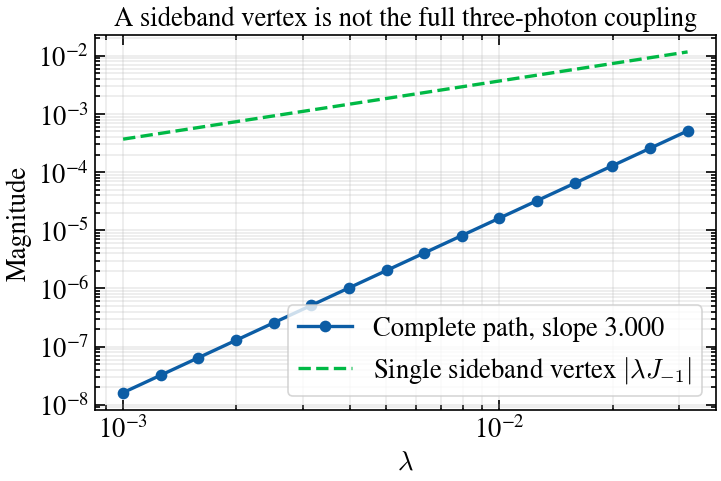

Fitted complete Floquet-path exponent: 3.000000


In [32]:
nu_static = 2.0 * omega_a_bare
G_sambe_static = -np.sqrt(6.0) * g_reference**3 / nu_static**2
G_static_reference = canonical_three_photon_coupling(
    omega_a_bare,
    omega_0,
    g_reference,
)

print(f"Static Sambe coupling     : {G_sambe_static:.12e}")
print(f"Canonical leading result : {G_static_reference:.12e}")
print(
    "Relative difference      : "
    f"{abs(G_sambe_static - G_static_reference) / abs(G_static_reference):.3e}"
)

x_modulation = 0.8
omega_bar_a = 0.1
lambda_values = np.logspace(-3.0, -1.5, 16)

J0 = jv(0, x_modulation)
Jm1 = jv(-1, x_modulation)

G_floquet_complete = (
    -np.sqrt(6.0)
    * lambda_values**3
    * Jm1
    * J0**2
    / (4.0 * omega_bar_a**2)
)
incorrect_single_vertex = lambda_values * Jm1

floquet_fit = np.polyfit(
    np.log(lambda_values),
    np.log(np.abs(G_floquet_complete)),
    1,
)

with plt.style.context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(6.2, 4.2))

    ax.loglog(
        lambda_values,
        np.abs(G_floquet_complete),
        marker="o",
        label=rf"Complete path, slope {floquet_fit[0]:.3f}",
    )
    ax.loglog(
        lambda_values,
        np.abs(incorrect_single_vertex),
        linestyle="--",
        label=r"Single sideband vertex $|\lambda J_{-1}|$",
    )

    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel("Magnitude")
    ax.set_title("A sideband vertex is not the full three-photon coupling")
    ax.legend(frameon=True)
    ax.grid(alpha=0.25, which="both")

    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / "N05_F16.pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        FIGURE_DIR / "N05_F16.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

print(f"Fitted complete Floquet-path exponent: {floquet_fit[0]:.6f}")

In [33]:
if RUN_DRIVEN_FLOQUET_EXTENSION:
    # Optional advanced experiment: one-period propagator of the driven
    # laboratory Hamiltonian. This cell is intentionally visible rather
    # than hidden in a helper package.
    Omega_c = 1.0
    Omega_0 = 1.2
    delta_drive = Omega_0 - Omega_c
    Delta_f = 2.0 * delta_drive
    omega_f = Omega_0 + Omega_c - Delta_f
    A_drive = x_modulation * omega_f
    lambda_drive = 0.01
    N_drive = 10

    drive_operators = build_operators(N_drive)
    H_static_drive = (
        Omega_c * drive_operators["number"]
        + 0.5 * Omega_0 * drive_operators["sigma_z"]
        + lambda_drive
        * (drive_operators["a"] + drive_operators["a"].dag())
        * drive_operators["sigma_x"]
    )
    H_modulation = 0.5 * A_drive * drive_operators["sigma_z"]

    def cosine_drive(t, args):
        return np.cos(args["omega_f"] * t)

    H_driven = [
        H_static_drive,
        [H_modulation, cosine_drive],
    ]
    drive_args = {"omega_f": omega_f}
    drive_period = 2.0 * np.pi / omega_f

    U_period = qt.propagator(
        H_driven,
        drive_period,
        args=drive_args,
        options={"atol": 1e-10, "rtol": 1e-10, "nsteps": 100000},
    )

    floquet_multipliers, floquet_modes = U_period.eigenstates()
    quasienergies = -np.angle(np.asarray(floquet_multipliers)) / drive_period
    ordering = np.argsort(quasienergies)
    quasienergies = quasienergies[ordering]

    print(f"Drive frequency omega_f = {omega_f:.6f}")
    print("First ten quasienergies in the principal zone:")
    print(quasienergies[:10])
else:
    print(
        "The optional laboratory-frame Floquet propagator is disabled. "
        "Set RUN_DRIVEN_FLOQUET_EXTENSION=True to execute it."
    )

The optional laboratory-frame Floquet propagator is disabled. Set RUN_DRIVEN_FLOQUET_EXTENSION=True to execute it.


## 23. Validity map and error budget

The effective prediction is controlled by more than a single number. Relevant diagnostics include:

- the retained-space weights of the selected exact doublet;
- convergence with oscillator cutoff;
- the relative error in the shifted resonance;
- the relative error in the minimum gap;
- the maximum virtual-state population;
- the state fidelity after reconstruction;
- the ratio $|\delta_3/G_3|$;
- method-specific quantities such as filter response, generator size, or sideband separation.

A useful validity statement must identify the observable and comparison time. A coupling can reproduce the avoided-crossing gap accurately while accumulating a visible phase error over several transfer periods.

In [34]:
validity_rows = []

for row in saved_scaling:
    g_value = float(row["g"])
    validity_rows.append(
        (
            g_value / omega_0,
            float(row["minimum_retained_weight"]),
            float(
                abs(
                    row["omega_a_exact_resonance"]
                    - row["omega_a_delta3_root"]
                )
                / abs(row["omega_a_exact_resonance"])
            ),
            float(
                abs(row["exact_gap"] - row["analytical_gap"])
                / abs(row["exact_gap"])
            ),
        )
    )

validity_file = DATA_DIR / "N05_D12.csv"
np.savetxt(
    validity_file,
    np.asarray(validity_rows),
    delimiter=",",
    header=(
        "g_over_omega0,minimum_retained_weight,"
        "resonance_relative_error,gap_relative_error"
    ),
    comments="",
)

print("g/omega0 | min retained weight | resonance error | gap error")
for values in validity_rows:
    print(
        f"{values[0]:8.3f} | "
        f"{values[1]:19.8f} | "
        f"{values[2]:15.3e} | "
        f"{values[3]:9.3e}"
    )


g/omega0 | min retained weight | resonance error | gap error
   0.010 |          0.99943845 |       8.087e-07 | 1.012e-03
   0.014 |          0.99890111 |       3.102e-06 | 1.982e-03
   0.018 |          0.99818728 |       8.459e-06 | 3.273e-03
   0.022 |          0.99729912 |       1.883e-05 | 4.885e-03
   0.028 |          0.99564590 |       4.916e-05 | 7.896e-03
   0.034 |          0.99361710 |       1.063e-04 | 1.161e-02
   0.040 |          0.99122522 |       2.021e-04 | 1.603e-02
   0.046 |          0.98848435 |       3.507e-04 | 2.113e-02
   0.050 |          0.98647074 |       4.867e-04 | 2.490e-02


## 24. Pitfall laboratory

The following tests deliberately perform incomplete or inconsistent calculations. Each test is designed to reveal a physical failure rather than merely a programming error.

### Pitfall 1: energy matching without parity

Energy degeneracy is not sufficient. States of opposite Rabi parity cannot hybridize unless the symmetry is broken.

### Pitfall 2: applying the ordinary RWA

The JC Hamiltonian removes the counter-rotating middle step and therefore gives a crossing rather than the cubic avoided crossing.

### Pitfall 3: using the bare resonance

The uncorrected $O(g^2)$ detuning overwhelms the $O(g^3)$ coupling.

### Pitfall 4: omitting $|e,4\rangle$

A virtual state outside the shortest path still changes the endpoint self-energy.

### Pitfall 5: confusing an energy branch with a bare-state identity

Across an avoided crossing, the lower and upper adiabatic branches exchange their $|A\rangle$ and $|B\rangle$ character.

### Pitfall 6: using a cutoff that only contains the target state

A cutoff can include $|g,3\rangle$ while excluding virtual states required for the correct shift or reconstruction.

### Pitfall 7: confusing coupling, gap, and period

$G_3$, $2|G_3|$, and $\pi/|G_3|$ are different quantities.

### Pitfall 8: interpreting virtual dressing as leakage

Bare target populations need not sum to one inside the retained sector.

### Pitfall 9: one-step adiabatic elimination

The first slaving step gives the diagonal shifts but not the cubic endpoint coupling.

### Pitfall 10: rotating away the resonant term

A generator proportional to $G_3/\delta_3$ is not perturbatively small in the resonant window.

### Pitfall 11: choosing the wrong coarse-graining window

A temporal filter can either retain unwanted carriers or suppress the desired slow beat.

### Pitfall 12: identifying one Floquet sideband vertex with the full process

The complete endpoint interaction remains cubic in the microscopic coupling.

In [35]:
from scipy.optimize import brentq

if RUN_EXTENDED_PITFALLS:
    ket_forbidden = bare_state(
        N_cav_reference,
        photon_number=4,
        qubit_label="g",
    )
    parity_forbidden = qt.expect(operators["parity"], ket_forbidden)

    print(f"Parity |e,0> : {parity_A:+.1f}")
    print(f"Parity |g,3> : {parity_B:+.1f}")
    print(f"Parity |g,4> : {parity_forbidden:+.1f}")

    assert np.isclose(parity_A, parity_B)
    assert not np.isclose(parity_A, parity_forbidden)

    def jc_hamiltonian(
        omega_a: float,
        omega_0: float,
        g: float,
        operators: dict[str, qt.Qobj],
    ) -> qt.Qobj:
        return (
            omega_a * operators["number"]
            + 0.5 * omega_0 * operators["sigma_z"]
            + g
            * (
                operators["a"] * operators["sigma_plus"]
                + operators["a"].dag() * operators["sigma_minus"]
            )
        )

    def jc_branch_difference(omega_a: float) -> float:
        """Energy difference between the JC branches connected to A and B."""
        energies, states = jc_hamiltonian(
            omega_a,
            omega_0,
            g_reference,
            operators,
        ).eigenstates()
        overlaps_A = np.array([abs(ket_A.overlap(state)) ** 2 for state in states])
        overlaps_B = np.array([abs(ket_B.overlap(state)) ** 2 for state in states])
        energy_A = float(np.real(energies[int(np.argmax(overlaps_A))]))
        energy_B = float(np.real(energies[int(np.argmax(overlaps_B))]))
        return energy_A - energy_B

    omega_jc_crossing = brentq(jc_branch_difference, 0.32, 0.35)
    jc_residual_gap = abs(jc_branch_difference(omega_jc_crossing))

    print(f"JC crossing frequency: {omega_jc_crossing / omega_0:.12f} omega_0")
    print(f"Residual gap at the tracked JC crossing: {jc_residual_gap:.3e}")
    print(
        "The rotating-wave model permits an exact crossing because its conserved "
        "excitation sectors do not couple. Counter-rotating terms in the full QRM "
        "connect the two states at third order and open the avoided crossing."
    )
    assert jc_residual_gap < 1e-11

Parity |e,0> : -1.0
Parity |g,3> : -1.0
Parity |g,4> : +1.0
JC crossing frequency: 0.334132496058 omega_0
Residual gap at the tracked JC crossing: 1.110e-16
The rotating-wave model permits an exact crossing because its conserved excitation sectors do not couple. Counter-rotating terms in the full QRM connect the two states at third order and open the avoided crossing.


In [36]:
def incomplete_delta_without_e4(
    omega_a: float,
    omega_0: float,
    g: float,
) -> float:
    Delta = omega_0 - omega_a
    return omega_0 - 3.0 * omega_a + 4.0 * g**2 / Delta


incomplete_root = root_scalar(
    incomplete_delta_without_e4,
    args=(omega_0, g_reference),
    bracket=(0.25 * omega_0, 0.42 * omega_0),
    method="brentq",
).root

print(f"Exact minimum-gap resonance     : {omega_a_exact_resonance:.12f}")
print(f"Complete second-order root      : {omega_a_shifted_root:.12f}")
print(f"Root after omitting |e,4>       : {incomplete_root:.12f}")
print(
    "Error from omitting |e,4>       : "
    f"{abs(incomplete_root - omega_a_exact_resonance):.3e}"
)

Exact minimum-gap resonance     : 0.334530109601
Complete second-order root      : 0.334534417235
Root after omitting |e,4>       : 0.334134295644
Error from omitting |e,4>       : 3.958e-04


In [37]:
if RUN_EXTENDED_PITFALLS:
    pitfall_cutoffs = [4, 5, 6, 8]
    print("Cutoff | includes e4 | includes g5 | exact resonance | exact gap")

    for N_test in pitfall_cutoffs:
        includes_e4 = N_test > 4
        includes_g5 = N_test > 5

        local_scan = np.linspace(
            omega_a_shifted_root - 0.0015,
            omega_a_shifted_root + 0.0015,
            101,
        )
        local_gaps = np.array(
            [
                exact_three_photon_gap(
                    omega_a,
                    omega_0,
                    g_reference,
                    N_test,
                )
                for omega_a in local_scan
            ]
        )
        index = int(np.argmin(local_gaps))
        center = local_scan[index]
        spacing = local_scan[1] - local_scan[0]
        result = minimize_scalar(
            exact_three_photon_gap,
            bounds=(center - 4 * spacing, center + 4 * spacing),
            args=(omega_0, g_reference, N_test),
            method="bounded",
        )

        print(
            f"{N_test:6d} | "
            f"{str(includes_e4):11s} | "
            f"{str(includes_g5):11s} | "
            f"{result.x:.10f} | "
            f"{result.fun:.6e}"
        )

Cutoff | includes e4 | includes g5 | exact resonance | exact gap
     4 | False       | False       | 0.3341302936 | 8.779129e-05
     5 | True        | False       | 0.3345280932 | 8.773517e-05
     6 | True        | True        | 0.3345290799 | 8.772367e-05
     8 | True        | True        | 0.3345290817 | 8.772365e-05


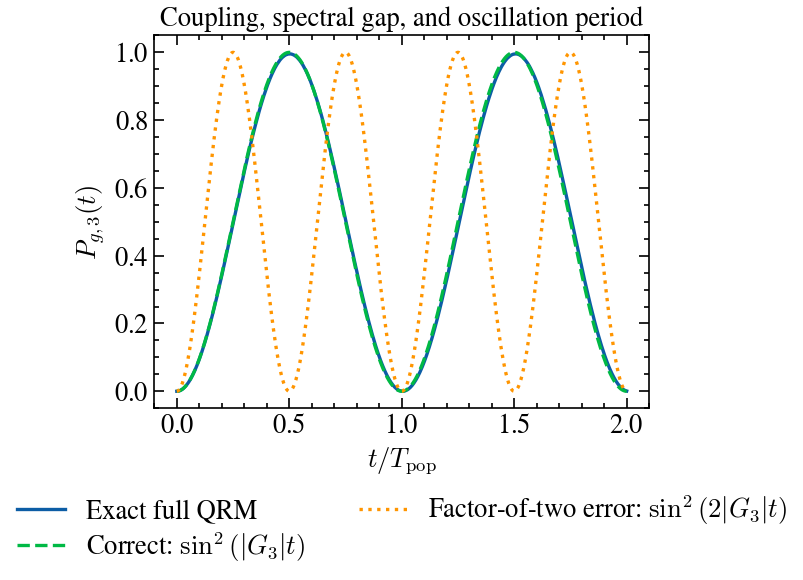

In [38]:
if RUN_DYNAMICS:
    correct_population = np.sin(abs(G_reference) * tlist_dynamics) ** 2
    wrong_population = np.sin(2.0 * abs(G_reference) * tlist_dynamics) ** 2

    with plt.style.context(PLOT_STYLE):
        fig, ax = plt.subplots(figsize=(6.2, 5.2))

        ax.plot(
            normalized_time,
            exact_dynamics["exact"]["probabilities"]["B_g3"],
            label="Exact full QRM",
        )
        ax.plot(
            normalized_time,
            correct_population,
            linestyle="--",
            label=r"Correct: $\sin^2(|G_3|t)$",
        )
        ax.plot(
            normalized_time,
            wrong_population,
            linestyle=":",
            label=r"Factor-of-two error: $\sin^2(2|G_3|t)$",
        )

        ax.set_xlabel(r"$t/T_{\mathrm{pop}}$")
        ax.set_ylabel(r"$P_{g,3}(t)$")
        ax.set_title("Coupling, spectral gap, and oscillation period")
        ax.legend(loc="upper center",bbox_to_anchor=(0.5, -0.20),ncol=2,frameon=False,handlelength=1.8,labelspacing=0.20,borderaxespad=0.0,)

        fig.tight_layout()
        fig.savefig(
            FIGURE_DIR / "N05_F17.pdf",
            bbox_inches="tight",
        )
        fig.savefig(
            FIGURE_DIR / "N05_F17.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

In [39]:
Lambda = 0.5 * (omega_0 + omega_a_exact_resonance)

H_ae_one_step = np.array(
    [
        [g_reference**2 / Lambda, 0.0],
        [0.0, -3.0 * g_reference**2 / Lambda],
    ]
)

G_ae_second_iteration = -np.sqrt(6.0) * g_reference**3 / Lambda**2
H_ae_two_step = H_ae_one_step.copy()
H_ae_two_step[0, 1] = G_ae_second_iteration
H_ae_two_step[1, 0] = G_ae_second_iteration

print("One-step AE endpoint coupling :", H_ae_one_step[1, 0])
print("Two-step AE endpoint coupling :", H_ae_two_step[1, 0])
print("Canonical endpoint coupling   :", G_reference)

assert np.isclose(H_ae_one_step[1, 0], 0.0)

One-step AE endpoint coupling : 0.0
Two-step AE endpoint coupling : -4.401177154634847e-05
Canonical endpoint coupling   : -4.4011808270492565e-05


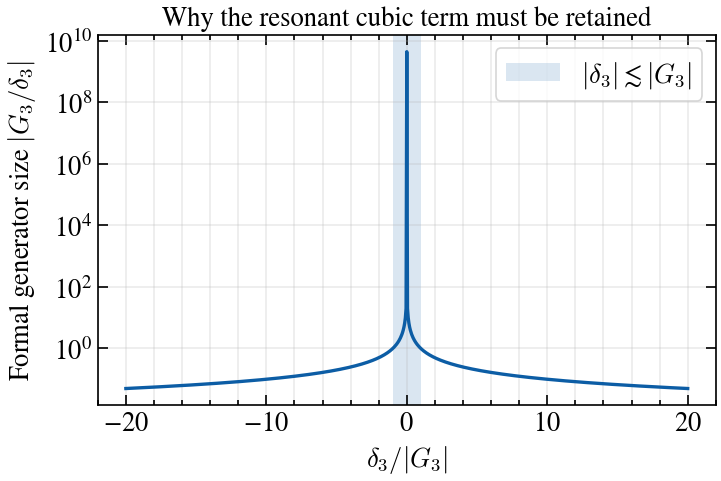

In [40]:
detuning_test = np.linspace(
    -20.0 * abs(G_reference),
    20.0 * abs(G_reference),
    801,
)
generator_ratio = abs(G_reference) / np.maximum(
    np.abs(detuning_test),
    1e-14,
)

with plt.style.context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(6.2, 4.2))

    ax.semilogy(
        detuning_test / abs(G_reference),
        generator_ratio,
    )
    ax.axvspan(-1.0, 1.0, alpha=0.15, label=r"$|\delta_3|\lesssim|G_3|$")
    ax.set_xlabel(r"$\delta_3/|G_3|$")
    ax.set_ylabel(r"Formal generator size $|G_3/\delta_3|$")
    ax.set_title("Why the resonant cubic term must be retained")
    ax.legend(frameon=True)
    ax.grid(alpha=0.25, which="both")

    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / "N05_F18.pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        FIGURE_DIR / "N05_F18.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

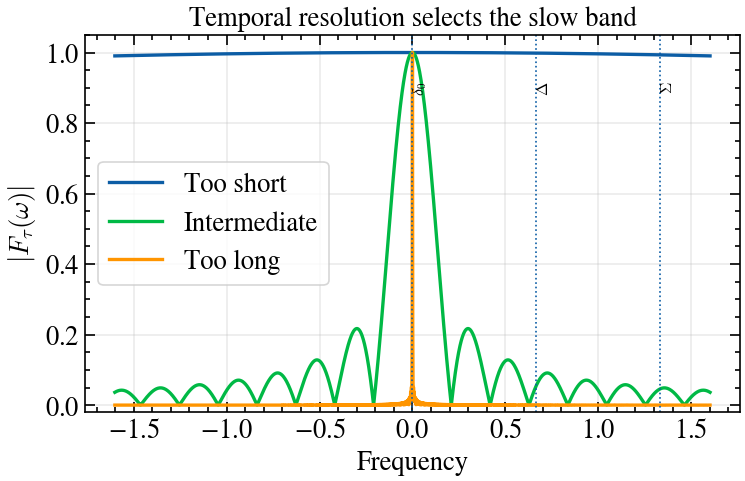

In [41]:
def boxcar_filter_response(omega: np.ndarray, tau: float) -> np.ndarray:
    """Symmetric boxcar response F_tau(omega)=sinc(omega*tau/2)."""
    return np.sinc(omega * tau / (2.0 * np.pi))


delta0_reference = omega_0 - 3.0 * omega_a_shifted_root
Delta_reference = omega_0 - omega_a_shifted_root
Sigma_reference = omega_0 + omega_a_shifted_root

tau_short = 0.2 / abs(Delta_reference)
tau_good = 20.0 / abs(Delta_reference)
tau_too_long = 20.0 / max(abs(delta0_reference), 1e-12)

frequency_axis = np.linspace(
    -1.2 * Sigma_reference,
    1.2 * Sigma_reference,
    2001,
)

with plt.style.context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(6.4, 4.2))

    for tau, label in [
        (tau_short, "Too short"),
        (tau_good, "Intermediate"),
        (tau_too_long, "Too long"),
    ]:
        ax.plot(
            frequency_axis,
            np.abs(boxcar_filter_response(frequency_axis, tau)),
            label=label,
        )

    for frequency, label in [
        (delta0_reference, r"$\delta_0$"),
        (Delta_reference, r"$\Delta$"),
        (Sigma_reference, r"$\Sigma$"),
    ]:
        ax.axvline(frequency, linestyle=":", linewidth=1.0)
        ax.text(frequency, 0.92, label, rotation=90, va="top")

    ax.set_xlabel("Frequency")
    ax.set_ylabel(r"$|F_\tau(\omega)|$")
    ax.set_title("Temporal resolution selects the slow band")
    ax.set_ylim(-0.02, 1.05)
    ax.legend(frameon=True)
    ax.grid(alpha=0.25)

    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / "N05_F19.pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        FIGURE_DIR / "N05_F19.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

### QuTiP propagation cross-check

The long time-series calculations below use a spectral representation of the
QuTiP Hamiltonian as a vectorized acceleration. To ensure that this acceleration
has not changed the quantum dynamics, one representative trajectory is compared
directly with `qutip.sesolve`.

In [42]:
omega_check = omega_a_shifted_root
H_check = rabi_hamiltonian(
    omega_check,
    omega_0,
    g_reference,
    build_operators(N_cav_reference),
)
G_check = canonical_three_photon_coupling(
    omega_check, omega_0, g_reference
)
Tpop_check = np.pi / abs(G_check)
t_check = np.linspace(0.0, Tpop_check, 121)

targets_check = full_target_states(N_cav_reference)
fast_check = spectral_evolution(
    H_check,
    bare_state(N_cav_reference, 0, "e"),
    t_check,
    {"B_g3": targets_check["B_g3"]},
)

sesolve_check = qt.sesolve(
    H_check,
    bare_state(N_cav_reference, 0, "e"),
    t_check,
    e_ops=[targets_check["B_g3"] * targets_check["B_g3"].dag()],
    options={
        "method": "dop853",
        "atol": 1e-11,
        "rtol": 1e-9,
        "nsteps": 30000,
        "progress_bar": False,
    },
)
sesolve_population = np.asarray(sesolve_check.expect[0], dtype=float)
spectral_population = np.asarray(fast_check["probabilities"]["B_g3"], dtype=float)
qutip_propagation_residual = np.max(
    np.abs(sesolve_population - spectral_population)
)

print(f"QuTiP/spectral population residual: {qutip_propagation_residual:.3e}")
assert qutip_propagation_residual < 5e-7

QuTiP/spectral population residual: 2.117e-07


### 24.13 Automated physical checks

These assertions are placed after the associated derivations and numerical diagnostics. They are not substitutes for inspecting the plots. Their tolerances belong to the parameter range and numerical settings of this notebook rather than constituting universal accuracy thresholds.

In [43]:
shift_tolerance = 0.10
gap_tolerance = 0.10
manuscript_shift_target = 1.990
manuscript_gap_target = 2.979
manuscript_fit_tolerance = 0.025
cutoff_tolerance = 1e-8
retained_weight_threshold = 0.90

assert np.isclose(parity_A, parity_B)

# Asymptotic physics.
assert abs(shift_exponent_weak - 2.0) < shift_tolerance
assert abs(gap_exponent_weak - 3.0) < gap_tolerance

# Exact alignment with the finite coupling range used by the article.
assert abs(
    shift_exponent_manuscript - manuscript_shift_target
) < manuscript_fit_tolerance
assert abs(
    gap_exponent_manuscript - manuscript_gap_target
) < manuscript_fit_tolerance

cutoff_relative_change = abs(
    saved_cutoff["exact_minimum_gap"][-2]
    - saved_cutoff["exact_minimum_gap"][-1]
) / abs(saved_cutoff["exact_minimum_gap"][-1])
assert cutoff_relative_change < cutoff_tolerance

assert (
    np.min(saved_scaling["minimum_retained_weight"])
    > retained_weight_threshold
)

if RUN_DYNAMICS:
    maximum_bare_transfer = np.max(
        exact_dynamics["bare"]["probabilities"]["B_g3"]
    )
    maximum_perturbative_transfer = np.max(
        exact_dynamics["perturbative"]["probabilities"]["B_g3"]
    )
    maximum_calibrated_transfer = np.max(
        exact_dynamics["exact"]["probabilities"]["B_g3"]
    )
    maximum_ideal_two_state_transfer = np.max(
        manuscript_effective_dynamics["population_B"]
    )

    assert maximum_perturbative_transfer > maximum_bare_transfer
    assert maximum_calibrated_transfer > maximum_perturbative_transfer
    assert maximum_ideal_two_state_transfer > 0.99

assert abs(floquet_fit[0] - 3.0) < 1e-10
assert qutip_propagation_residual < 5e-7

print("All enabled physical checks passed.")

All enabled physical checks passed.


## 25. Physics exercises and numerical experiments

1. Extend the coupling sweep toward $g/\omega_0=0.1$. At what value does the local logarithmic gap slope visibly depart from three?
2. Fit the first correction to the cubic gap. Is the leading relative correction consistent with an even power of $g$?
3. Determine how the maximum populations of $|g,1\rangle$, $|e,2\rangle$, and $|e,4\rangle$ scale with $g$.
4. Compare a bare preparation with a reconstructed dressed preparation during the first ten fast periods.
5. Add a small parity-breaking term and search for an even-photon avoided crossing.
6. Replace overlap-based doublet selection with a fixed eigenvalue index. Introduce a nearby crossing and identify where the fixed-index procedure fails.
7. Introduce a phenomenological linewidth. For which couplings is $2|G_3|$ spectroscopically resolvable?
8. Compare continuous-time dynamics with stroboscopic samples separated by the fast period.
9. Vary the James--Jerke filter width and map the attenuation $|F_\tau(\delta_0)|$ of the effective coupling.
10. Increase the modulation amplitude and determine how many Floquet sidebands are required for convergence.
11. Compare the raw method coefficients outside the resonant scaling window. Which discrepancies are genuine breakdowns rather than effective-gauge differences?
12. Construct a parity-forbidden four-photon target and identify the perturbation required to activate it.

## 26. Validated conclusions

Within the tested weak-coupling and cutoff ranges,

$$
\omega_a^{\mathrm{res}}-\frac{\omega_0}{3}
\propto g^2,
$$

while

$$
\Delta_{\mathrm{gap}}^{(3\gamma)}
=
2|G_3|
\propto g^3.
$$

The counter-rotating middle step is required for the three-photon
interaction, whereas the resonance position also depends on virtual
states outside the shortest endpoint path. The lower-order resonance
displacement must therefore be calibrated before the higher-order
coupling can produce appreciable transfer.

The slow two-state Hamiltonian reproduces the coherent envelope near the
corrected resonance. Reconstruction accounts for the leading virtual
populations and improves the laboratory-frame state. Over longer times,
the remaining frequency error accumulates as a phase drift, so the
validity of the effective model must be stated together with a
comparison time.

The methods provide complementary information. Projection exposes
paths and denominators; Schrieffer--Wolff supplies dressed states and
control operators; small rotations expose generated nonlinear terms;
Magnus identifies coherent accumulation; James--Jerke relates the
reduction to temporal resolution; adiabatic elimination identifies
slaving and initial slip; and Floquet--Sambe provides a frequency-space
route to resonance engineering.

For an interaction not known in advance, symmetry, graph connectivity,
near-degeneracy, and shortest-path order provide an operational
discovery procedure. Quantitative reduction, reconstruction, and
comparison with the full model then determine whether the candidate
interaction is physically useful.

## Adapting the workflow to a related high-order resonance

For another multiphoton or multimode problem, the calculation should be rebuilt in
the following order rather than by changing the power of $g$ in the final answer:

1. identify the symmetry sector and the candidate retained manifold;
2. enumerate all shortest virtual paths and their matrix elements;
3. compute lower-order diagonal shifts before imposing the resonance condition;
4. derive the first nonzero off-diagonal retained coupling;
5. reconstruct the leading eliminated-state amplitudes and observables;
6. validate branch tracking, cutoff convergence, and scaling independently;
7. compare on both a slow rescaled time and a fixed physical observation window;
8. if the fast gap closes or a nearby crossing enters the window, enlarge the
   retained model rather than merely increasing perturbative order.

This is the transferable lesson of the three-photon benchmark: high-order
interaction strength, resonance placement, reconstruction, and predictive time
belong to one effective prediction.

## References

### Three-photon and multiphoton Rabi physics

1. K. K. W. Ma and C. K. Law, “Three-photon resonance and adiabatic passage in
   the large-detuning Rabi model,” *Phys. Rev. A* **92**, 023842 (2015).
2. L. Garziano, R. Stassi, V. Macrì, A. F. Kockum, S. Savasta, and F. Nori,
   “Multiphoton quantum Rabi oscillations in ultrastrong cavity QED,”
   *Phys. Rev. A* **92**, 063830 (2015).
3. K.-X. Yan, Y. Qiu, Y. Xiao, Y.-H. Chen, and Y. Xia,
   “Generating three-photon Rabi oscillations without a large-detuning condition,”
   *Phys. Rev. A* **110**, 043711 (2024).
4. A. P. Costa and A. V. Dodonov, “One- and multiphoton resonances in the
   light-atom interaction,” arXiv:2509.00985 (2025).

### Effective-model and arbitrary-order methods

5. S. Bravyi, D. P. DiVincenzo, and D. Loss,
   “Schrieffer--Wolff transformation for quantum many-body systems,”
   *Ann. Phys.* **326**, 2793 (2011).
6. D. F. V. James and J. Jerke,
   “Effective Hamiltonian theory and its applications in quantum information,”
   *Can. J. Phys.* **85**, 625 (2007).
7. W. Magnus, “On the exponential solution of differential equations for a
   linear operator,” *Commun. Pure Appl. Math.* **7**, 649 (1954).
8. L. Huang, J. Luneau, J. Schirk, F. Wallner, C. M. F. Schneider,
   S. Filipp, K. Liegener, and P. Rabl,
   “Theory of multiphoton processes for applications in quantum control,”
   *Phys. Rev. A* **113**, 032620 (2026).

### Related experimental perspective

9. I. I. Beterov *et al.*, “Rabi oscillations at three-photon laser excitation
   of a single rubidium Rydberg atom in an optical dipole trap,”
   *J. Exp. Theor. Phys.* **166** (2024). This is a distinct multistep laser
   process and is included to emphasize that identical photon order does not imply
   an identical microscopic mechanism.

### Software

10. N. Lambert *et al.*, “QuTiP 5: The Quantum Toolbox in Python,”
    *Physics Reports* **1153**, 1--62 (2026).

## Figure-generation appendix

The calculations above generate many diagnostic plots. The canonical manuscript figure is accompanied here by a second composite diagnostic for reconstruction and long-time error. The manuscript figure establishes the three-photon mechanism and the order-consistent spectral and dynamical predictions. The additional composite diagnostic tests reconstruction, preparation, and the finite time horizon of the effective description.

The individual diagnostic plots expose convergence, reconstruction, and failure modes in greater detail than the compact manuscript figure. The composite figures below use the same saved numerical arrays and contain no additional fitting assumptions.

In [44]:
# Compact article typography. Apply this rc context after SciencePlots so
# the notebook style cannot overwrite the publication font sizes.
MANUSCRIPT_RC = {
    "figure.dpi": 120,
    "savefig.dpi": 400,
    "font.size": 8.0,
    "axes.labelsize": 8.0,
    "axes.titlesize": 8.2,
    "legend.fontsize": 6.7,
    "xtick.labelsize": 7.2,
    "ytick.labelsize": 7.2,
    "axes.linewidth": 0.75,
    "lines.linewidth": 1.35,
    "lines.markersize": 3.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "mathtext.fontset": "stix",
}


def panel_label(ax, label):
    ax.text(
        -0.13,
        1.04,
        label,
        transform=ax.transAxes,
        fontsize=8.4,
        fontweight="bold",
        va="bottom",
        ha="left",
    )


def finish_axis(ax, grid=True):
    ax.tick_params(direction="out", length=2.8, width=0.65)
    if grid:
        ax.grid(alpha=0.16, linewidth=0.55)


### A.1 Virtual pathway, resonance calibration, scaling, and transfer

The article figure is generated only from the archived spectral and dynamical
tables. Panel (a) separates the retained endpoints from the eliminated virtual
states and identifies the counter-rotating vertex that makes the process
possible. Panel (b) shows why the second-order resonance displacement must be
included before the cubic gap can be resolved. Panel (c) tests the expected
quadratic displacement and cubic gap on the weak-coupling subset. Panel (d)
compares the full Rabi dynamics at the bare and analytically shifted resonance
with the shifted two-state prediction; it does not use numerical calibration as
an input to the predictive curve.


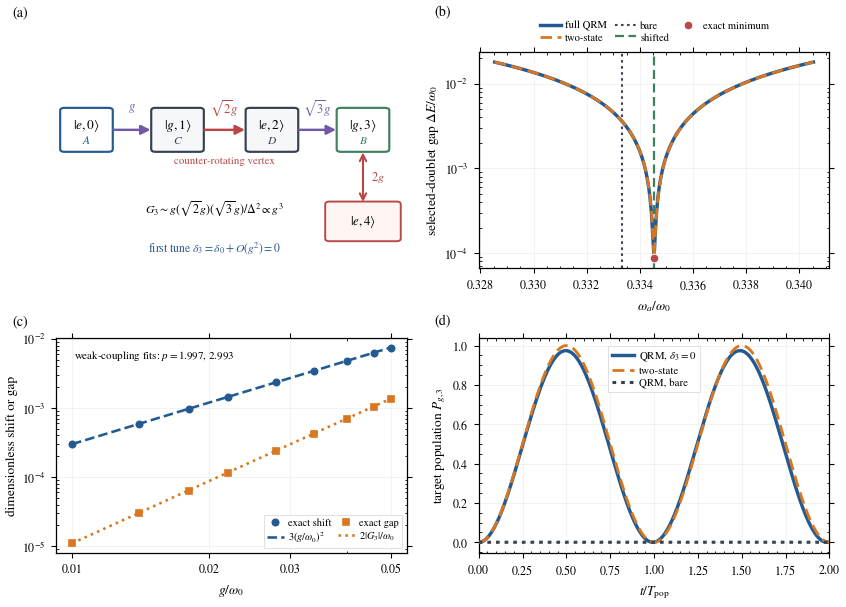

In [45]:
if RUN_DYNAMICS:
    from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
    from matplotlib.ticker import NullFormatter
    from scipy.optimize import brentq

    # ------------------------------------------------------------------
    # Load archived data
    # ------------------------------------------------------------------
    scan = np.genfromtxt(
        DATA_DIR / "N05_D2.csv",
        delimiter=",",
        names=True,
    )
    scaling = np.genfromtxt(
        DATA_DIR / "N05_D4.csv",
        delimiter=",",
        names=True,
    )
    dynamics = np.genfromtxt(
        DATA_DIR / "N05_D6.csv",
        delimiter=",",
        names=True,
    )

    omega_zero = 1.0
    g_plot = 0.02
    omega_bare = omega_zero / 3.0

    def delta_three_photon_plot(omega_a):
        Delta = omega_zero - omega_a
        Sigma = omega_zero + omega_a

        return (
            omega_zero
            - 3.0 * omega_a
            + 4.0 * g_plot**2
            * (1.0 / Delta + 1.0 / Sigma)
        )

    omega_shifted = brentq(
        delta_three_photon_plot,
        0.25,
        0.42,
    )

    exact_minimum_index = int(
        np.argmin(scan["exact_gap"])
    )
    omega_exact = float(
        scan["omega_a"][exact_minimum_index]
    )
    exact_minimum_gap = float(
        scan["exact_gap"][exact_minimum_index]
    )

    # ------------------------------------------------------------------
    # Scaling data and weak-coupling fits
    # ------------------------------------------------------------------
    x_scaling = (
        scaling["g"] / omega_zero
    )
    exact_shift = (
        scaling["omega_a_exact_resonance"]
        - omega_bare
    ) / omega_zero
    leading_shift = (
        scaling["omega_a_leading_shifted"]
        - omega_bare
    ) / omega_zero
    exact_gap = (
        scaling["exact_gap"] / omega_zero
    )
    leading_gap = (
        scaling["analytical_gap"] / omega_zero
    )

    weak = slice(0, 4)

    shift_fit = float(
        np.polyfit(
            np.log(x_scaling[weak]),
            np.log(exact_shift[weak]),
            1,
        )[0]
    )
    gap_fit = float(
        np.polyfit(
            np.log(x_scaling[weak]),
            np.log(exact_gap[weak]),
            1,
        )[0]
    )

    # ------------------------------------------------------------------
    # Manuscript palette
    # ------------------------------------------------------------------
    blue = "#245A92"
    orange = "#D97720"
    green = "#3F815F"
    purple = "#705AA6"
    red = "#B84747"
    gray = "#374151"
    light_gray = "#D9DEE3"
    pale = "#F5F7F9"

    def safe_panel_label(
        ax,
        label,
        y=1.045,
    ):
        ax.text(
            -0.125,
            y,
            label,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=8.5,
            fontweight="normal",
            clip_on=False,
            zorder=20,
        )

    def style_boxed_legend(legend):
        frame = legend.get_frame()
        frame.set_facecolor("white")
        frame.set_alpha(0.96)
        frame.set_edgecolor(light_gray)
        frame.set_linewidth(0.55)

    # ------------------------------------------------------------------
    # Build the manuscript figure
    # ------------------------------------------------------------------
    with (
        plt.style.context(
            ["science", "no-latex"]
        ),
        plt.rc_context(MANUSCRIPT_RC),
    ):
        fig, axes = plt.subplots(
            2,
            2,
            figsize=(7.2, 5.25),
            constrained_layout=False,
        )

        # The larger upper margin provides a dedicated legend band for
        # panel (b). Nothing is placed over its spectroscopy curves.
        fig.subplots_adjust(
            left=0.090,
            right=0.985,
            bottom=0.105,
            top=0.900,
            wspace=0.205,
            hspace=0.325,
        )

        ax_a, ax_b, ax_c, ax_d = axes.flat

        # ==============================================================
        # (a) Virtual pathway and separate diagonal dressing
        # ==============================================================
        ax_a.set_xlim(0.0, 1.04)
        ax_a.set_ylim(0.0, 1.0)
        ax_a.axis("off")

        state_y = 0.64
        box_half_width = 0.066
        box_height = 0.18

        states = [
            (
                0.09,
                state_y,
                r"$|e,0\rangle$",
                r"$A$",
                blue,
                True,
            ),
            (
                0.36,
                state_y,
                r"$|g,1\rangle$",
                r"$C$",
                gray,
                False,
            ),
            (
                0.64,
                state_y,
                r"$|e,2\rangle$",
                r"$D$",
                gray,
                False,
            ),
            (
                0.91,
                state_y,
                r"$|g,3\rangle$",
                r"$B$",
                green,
                True,
            ),
        ]

        for (
            x,
            y,
            ket,
            name,
            color,
            retained,
        ) in states:
            ax_a.add_patch(
                FancyBboxPatch(
                    (
                        x - box_half_width,
                        y - box_height / 2.0,
                    ),
                    2.0 * box_half_width,
                    box_height,
                    boxstyle="round,pad=0.012",
                    facecolor=(
                        "white"
                        if retained
                        else pale
                    ),
                    edgecolor=color,
                    linewidth=1.30,
                )
            )

            ax_a.text(
                x,
                y + 0.022,
                ket,
                ha="center",
                va="center",
                fontsize=8.0,
            )
            ax_a.text(
                x,
                y - 0.047,
                name,
                ha="center",
                va="center",
                color=color,
                fontsize=6.9,
            )

        vertices = [
            r"$g$",
            r"$\sqrt{2}g$",
            r"$\sqrt{3}g$",
        ]
        vertex_colors = [
            purple,
            red,
            purple,
        ]

        # Narrower boxes and explicit endpoint offsets produce arrows
        # long enough to remain readable after two-column scaling.
        for i, (
            vertex,
            color,
        ) in enumerate(
            zip(
                vertices,
                vertex_colors,
            )
        ):
            x0 = (
                states[i][0]
                + box_half_width
                + 0.014
            )
            x1 = (
                states[i + 1][0]
                - box_half_width
                - 0.014
            )

            ax_a.add_patch(
                FancyArrowPatch(
                    (x0, state_y),
                    (x1, state_y),
                    arrowstyle="-|>",
                    mutation_scale=11.5,
                    linewidth=1.45,
                    color=color,
                    shrinkA=0.0,
                    shrinkB=0.0,
                    zorder=3,
                )
            )

            # A small white backing separates each coupling label from
            # the arrow, box borders, and neighboring labels.
            ax_a.text(
                0.5 * (x0 + x1),
                0.742,
                vertex,
                ha="center",
                va="center",
                color=color,
                fontsize=7.5,
                bbox={
                    "facecolor": "white",
                    "edgecolor": "none",
                    "pad": 0.35,
                },
                zorder=5,
            )

        ax_a.text(
            0.50,
            0.495,
            "counter-rotating vertex",
            ha="center",
            va="center",
            color=red,
            fontsize=6.5,
        )

        # Separate self-energy branch
        ax_a.add_patch(
            FancyBboxPatch(
                (0.81, 0.135),
                0.20,
                0.16,
                boxstyle="round,pad=0.012",
                facecolor="#FFF6F4",
                edgecolor=red,
                linewidth=1.15,
            )
        )

        ax_a.text(
            0.91,
            0.215,
            r"$|e,4\rangle$",
            ha="center",
            va="center",
            fontsize=7.8,
        )

        ax_a.add_patch(
            FancyArrowPatch(
                (0.91, 0.535),
                (0.91, 0.305),
                arrowstyle="<->",
                mutation_scale=9.5,
                linewidth=1.25,
                color=red,
                shrinkA=0.0,
                shrinkB=0.0,
                zorder=3,
            )
        )

        ax_a.text(
            0.935,
            0.420,
            r"$2g$",
            ha="left",
            va="center",
            color=red,
            fontsize=7.3,
        )

        ax_a.text(
            0.47,
            0.275,
            r"$G_3\sim g(\sqrt{2}g)(\sqrt{3}g)/\Delta^2\propto g^3$",
            ha="center",
            va="center",
            fontsize=7.15,
        )

        ax_a.text(
            0.47,
            0.095,
            r"first tune $\delta_3=\delta_0+O(g^2)=0$",
            ha="center",
            va="center",
            color=blue,
            fontsize=7.0,
        )

        safe_panel_label(
            ax_a,
            "(a)",
            y=1.155,
        )

        # ==============================================================
        # (b) Gap spectroscopy and resonance calibration
        # ==============================================================
        frequency_axis = (
            scan["omega_a"]
            / omega_zero
        )

        ax_b.semilogy(
            frequency_axis,
            scan["exact_gap"]
            / omega_zero,
            color=blue,
            linewidth=2.05,
            linestyle="-",
            label="full QRM",
            zorder=3,
        )

        ax_b.semilogy(
            frequency_axis,
            scan[
                "effective_two_state_gap"
            ] / omega_zero,
            color=orange,
            linewidth=1.65,
            linestyle=(0, (4.2, 2.0)),
            label="two-state",
            zorder=4,
        )

        ax_b.axvline(
            omega_bare / omega_zero,
            color=gray,
            linestyle=(0, (1.2, 1.7)),
            linewidth=1.25,
            label="bare",
            zorder=2,
        )

        ax_b.axvline(
            omega_shifted / omega_zero,
            color=green,
            linestyle=(0, (4.0, 2.0)),
            linewidth=1.35,
            label="shifted",
            zorder=2,
        )

        ax_b.plot(
            omega_exact / omega_zero,
            exact_minimum_gap / omega_zero,
            marker="o",
            linestyle="none",
            markerfacecolor=red,
            markeredgecolor="white",
            markeredgewidth=0.6,
            markersize=5.2,
            label="exact minimum",
            zorder=6,
        )

        ax_b.set_xlabel(
            r"$\omega_a/\omega_0$"
        )
        ax_b.set_ylabel(
            (
                r"selected-doublet gap "
                r"$\Delta E/\omega_0$"
            ),
            labelpad=2.0,
        )

        # The legend occupies the reserved band above the axes and
        # therefore cannot cover any curve or resonance marker.
        ax_b.legend(
            frameon=False,
            ncol=3,
            loc="lower center",
            bbox_to_anchor=(0.5, 1.025),
            fontsize=6.35,
            columnspacing=0.72,
            handlelength=2.0,
            handletextpad=0.42,
            labelspacing=0.20,
            borderaxespad=0.0,
        )

        finish_axis(ax_b)

        safe_panel_label(
            ax_b,
            "(b)",
            y=1.155,
        )

        # ==============================================================
        # (c) Quadratic resonance shift and cubic minimum gap
        # ==============================================================
        ax_c.loglog(
            x_scaling,
            exact_shift,
            "o",
            color=blue,
            label="exact shift",
            zorder=4,
        )

        ax_c.loglog(
            x_scaling,
            leading_shift,
            color=blue,
            linewidth=1.55,
            linestyle="--",
            label=r"$3(g/\omega_0)^2$",
            zorder=3,
        )

        ax_c.loglog(
            x_scaling,
            exact_gap,
            "s",
            color=orange,
            label="exact gap",
            zorder=4,
        )

        ax_c.loglog(
            x_scaling,
            leading_gap,
            color=orange,
            linewidth=1.55,
            linestyle=":",
            label=r"$2|G_3|/\omega_0$",
            zorder=3,
        )

        ax_c.set_xlabel(
            r"$g/\omega_0$"
        )
        ax_c.set_ylabel(
            "dimensionless shift or gap",
            labelpad=2.0,
        )

        ax_c.set_xticks(
            [
                0.01,
                0.02,
                0.03,
                0.05,
            ]
        )
        ax_c.set_xticklabels(
            [
                "0.01",
                "0.02",
                "0.03",
                "0.05",
            ]
        )
        ax_c.xaxis.set_minor_formatter(
            NullFormatter()
        )

        ax_c.text(
            0.05,
            0.95,
            (
                rf"weak-coupling fits: "
                rf"$p={shift_fit:.3f}$, "
                rf"${gap_fit:.3f}$"
            ),
            transform=ax_c.transAxes,
            ha="left",
            va="top",
            fontsize=6.6,
        )

        legend_c = ax_c.legend(
            frameon=True,
            fancybox=False,
            ncol=2,
            loc="lower right",
            fontsize=6.25,
            columnspacing=0.65,
            handlelength=1.60,
            handletextpad=0.40,
            labelspacing=0.22,
            borderpad=0.30,
        )
        style_boxed_legend(
            legend_c
        )

        finish_axis(ax_c)

        safe_panel_label(
            ax_c,
            "(c)",
        )

        # ==============================================================
        # (d) Predictive dynamics at the analytic shifted condition
        # ==============================================================
        time = (
            dynamics["t_over_Tpop"]
        )

        # Plot the bare-resonance result last and at high z-order so
        # that its near-zero trace remains visible above the grid.
        ax_d.plot(
            time,
            dynamics[
                "exact_B_perturbative"
            ],
            color=blue,
            linewidth=2.05,
            linestyle="-",
            label=r"QRM, $\delta_3=0$",
            zorder=3,
        )

        ax_d.plot(
            time,
            dynamics[
                "effective_B_perturbative"
            ],
            color=orange,
            linewidth=1.70,
            linestyle=(0, (4.2, 2.0)),
            label="two-state",
            zorder=4,
        )

        ax_d.plot(
            time,
            dynamics["exact_B_bare"],
            color=gray,
            linewidth=1.85,
            linestyle=(0, (1.2, 1.6)),
            label="QRM, bare",
            zorder=6,
        )

        ax_d.set_xlim(
            0.0,
            2.0,
        )

        # The negative lower margin prevents the near-zero gray trace
        # from being hidden by the bottom axis spine.
        ax_d.set_ylim(
            -0.055,
            1.04,
        )

        ax_d.set_xlabel(
            r"$t/T_{\rm pop}$"
        )
        ax_d.set_ylabel(
            r"target population $P_{g,3}$",
            labelpad=2.0,
        )

        # The central upper region lies between the two transfer peaks.
        # The opaque white legend does not cover any physical curve.
        legend_d = ax_d.legend(
            frameon=True,
            fancybox=False,
            ncol=1,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.985),
            fontsize=6.5,
            handlelength=2.0,
            handletextpad=0.45,
            labelspacing=0.23,
            borderpad=0.35,
        )
        style_boxed_legend(
            legend_d
        )

        finish_axis(ax_d)

        safe_panel_label(
            ax_d,
            "(d)",
        )

        # ------------------------------------------------------------------
        # Fixed-size vector and high-resolution exports
        # ------------------------------------------------------------------
        fig.savefig(
            MANUSCRIPT_FIGURE_DIR
            / "N05_MF1.pdf",
            facecolor="white",
        )

        fig.savefig(
            MANUSCRIPT_FIGURE_DIR
            / "N05_MF1.png",
            dpi=400,
            facecolor="white",
        )

        plt.show()
        plt.close(fig)

### A.2 Reconstruction, virtual dressing, and initial slip

The supplemental figure uses the same archived dynamics to test the endpoint
map, not only the retained two-state generator. It compares exact and
reconstructed target populations, the total and state-resolved virtual
populations, the reconstructed-state fidelity, and the fast transient produced
by bare rather than dressed preparation. No long-time spectral calibration is
used in this figure.


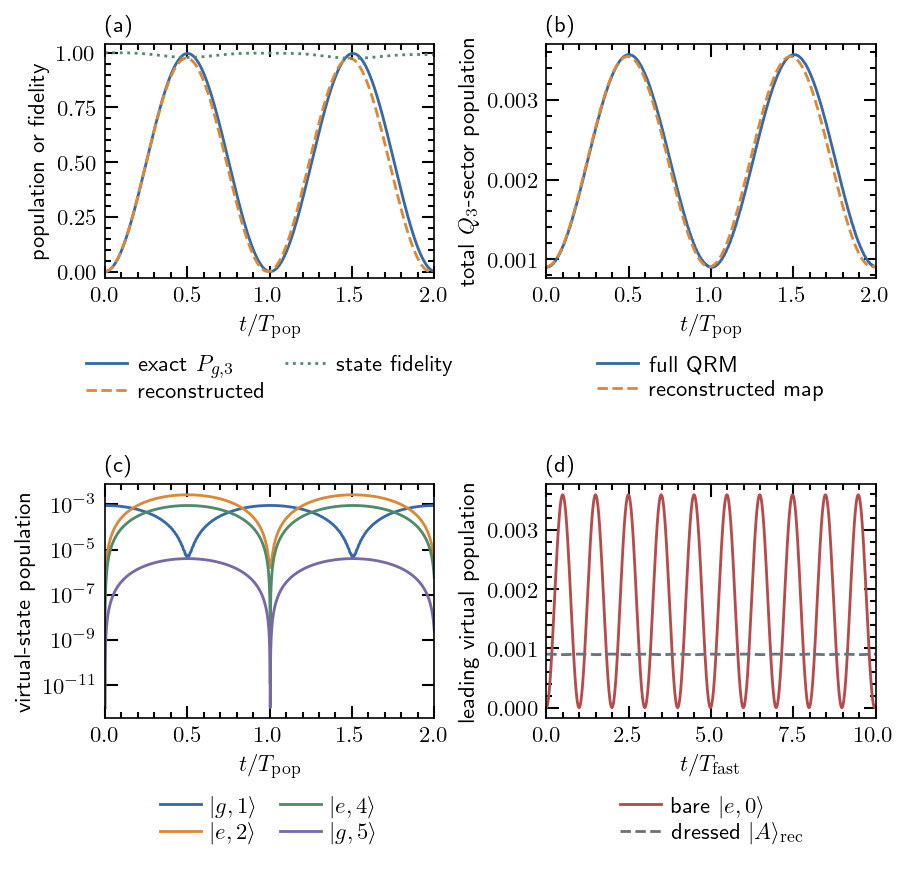

In [46]:
if RUN_DYNAMICS:
    reconstruction = np.genfromtxt(DATA_DIR / "N05_D7.csv", delimiter=",", names=True)
    initial_slip = np.genfromtxt(DATA_DIR / "N05_D10.csv", delimiter=",", names=True)
    SUPPLEMENT_FIGURE_DIR = NOTEBOOK_DIR / "figures" / "supplemental"
    SUPPLEMENT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    # ------------------------------------------------------------------
    # N08 manuscript standard: 150 mm physical width, SciPost/11-pt
    # typography, LaTeX rendering, and the same axis/curve thicknesses.
    # This rc context is local to this figure and does not alter the
    # numerical calculation or the formatting of other N05 figures.
    # ------------------------------------------------------------------
    FIG_WIDTH_150MM = 150.0 / 25.4
    SCIPOST_FONT_SIZE = 10.95
    N08_MANUSCRIPT_RC = {
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "text.usetex": True,
        "font.family": "serif",
        "font.size": SCIPOST_FONT_SIZE,
        "axes.labelsize": SCIPOST_FONT_SIZE,
        "axes.titlesize": SCIPOST_FONT_SIZE,
        "legend.fontsize": SCIPOST_FONT_SIZE,
        "xtick.labelsize": SCIPOST_FONT_SIZE,
        "ytick.labelsize": SCIPOST_FONT_SIZE,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.35,
        "lines.markersize": 4.2,
        "text.latex.preamble": r"\usepackage{amsmath}",
    }

    blue = "#3569A8"
    orange = "#D98938"
    green = "#4F8A69"
    purple = "#7967A8"
    red = "#B64B4B"
    gray = "#69737D"

    t_slow = reconstruction["t_over_Tpop"]
    exact_virtual = sum(
        reconstruction[key]
        for key in ("exact_C", "exact_D", "exact_F", "exact_G")
    )
    reconstructed_virtual = sum(
        reconstruction[key]
        for key in (
            "reconstructed_C",
            "reconstructed_D",
            "reconstructed_F",
            "reconstructed_G",
        )
    )

    with (
        plt.style.context(["science", "notebook"]),
        plt.rc_context(N08_MANUSCRIPT_RC),
    ):
        # Manual margins are used instead of bbox_inches="tight" so the
        # exported canvas remains exactly 150 mm wide.  The extra inter-row
        # space is occupied by legends, not left as unused white space.
        fig = plt.figure(
            figsize=(FIG_WIDTH_150MM, 5.55),
            constrained_layout=False,
        )
        gs = fig.add_gridspec(
            2,
            2,
            left=0.115,
            right=0.985,
            bottom=0.155,
            top=0.965,
            wspace=0.34,
            hspace=0.88,
        )
        ax_a = fig.add_subplot(gs[0, 0])
        ax_b = fig.add_subplot(gs[0, 1])
        ax_c = fig.add_subplot(gs[1, 0])
        ax_d = fig.add_subplot(gs[1, 1])

        # ==============================================================
        # (a)
        # ==============================================================
        ax_a.plot(
            t_slow,
            reconstruction["exact_B"],
            color=blue,
            label=r"exact $P_{g,3}$",
        )
        ax_a.plot(
            t_slow,
            reconstruction["reconstructed_B"],
            color=orange,
            linestyle="--",
            label="reconstructed",
        )
        ax_a.plot(
            t_slow,
            reconstruction["state_fidelity"],
            color=green,
            linestyle=":",
            label="state fidelity",
        )
        ax_a.set(
            xlabel=r"$t/T_{\rm pop}$",
            ylabel="population or fidelity",
            xlim=(0, 2),
            ylim=(-0.03, 1.04),
        )
        ax_a.set_title("(a)", loc="left")
        ax_a.legend(
            frameon=False,
            loc="upper center",
            bbox_to_anchor=(0.50, -0.29),
            ncol=2,
            handlelength=1.8,
            handletextpad=0.45,
            columnspacing=0.85,
            labelspacing=0.18,
            borderaxespad=0.0,
        )

        # ==============================================================
        # (b)
        # ==============================================================
        ax_b.plot(
            t_slow,
            exact_virtual,
            color=blue,
            label="full QRM",
        )
        ax_b.plot(
            t_slow,
            reconstructed_virtual,
            color=orange,
            linestyle="--",
            label="reconstructed map",
        )
        ax_b.set(
            xlabel=r"$t/T_{\rm pop}$",
            ylabel=r"total $Q_3$-sector population",
            xlim=(0, 2),
        )
        ax_b.set_title("(b)", loc="left")
        ax_b.legend(
            frameon=False,
            loc="upper center",
            bbox_to_anchor=(0.50, -0.29),
            ncol=1,
            handlelength=1.8,
            handletextpad=0.45,
            labelspacing=0.18,
            borderaxespad=0.0,
        )

        # ==============================================================
        # (c)
        # ==============================================================
        component_curves = [
            ("exact_C", r"$|g,1\rangle$", blue),
            ("exact_D", r"$|e,2\rangle$", orange),
            ("exact_F", r"$|e,4\rangle$", green),
            ("exact_G", r"$|g,5\rangle$", purple),
        ]
        for key, label, color in component_curves:
            ax_c.semilogy(
                t_slow,
                np.maximum(reconstruction[key], 1e-12),
                color=color,
                label=label,
            )
        ax_c.set(
            xlabel=r"$t/T_{\rm pop}$",
            ylabel="virtual-state population",
            xlim=(0, 2),
        )
        ax_c.set_title("(c)", loc="left")
        ax_c.legend(
            frameon=False,
            loc="upper center",
            bbox_to_anchor=(0.50, -0.29),
            ncol=2,
            handlelength=1.8,
            handletextpad=0.45,
            columnspacing=0.90,
            labelspacing=0.18,
            borderaxespad=0.0,
        )

        # ==============================================================
        # (d)
        # ==============================================================
        ax_d.plot(
            initial_slip["t_over_Tfast"],
            initial_slip["virtual_population_bare"],
            color=red,
            label=r"bare $|e,0\rangle$",
        )
        ax_d.plot(
            initial_slip["t_over_Tfast"],
            initial_slip["virtual_population_dressed"],
            color=gray,
            linestyle="--",
            label=r"dressed $|A\rangle_{\rm rec}$",
        )
        ax_d.set(
            xlabel=r"$t/T_{\rm fast}$",
            ylabel="leading virtual population",
            xlim=(0, 10),
        )
        ax_d.set_title("(d)", loc="left")
        ax_d.legend(
            frameon=False,
            loc="upper center",
            bbox_to_anchor=(0.50, -0.29),
            ncol=1,
            handlelength=1.8,
            handletextpad=0.45,
            labelspacing=0.18,
            borderaxespad=0.0,
        )

        # Match N08 typography explicitly on every axis.  No numerical
        # limits, plotted data, colors, or curve linestyles are changed.
        for ax in (ax_a, ax_b, ax_c, ax_d):
            ax.tick_params(axis="both", labelsize=SCIPOST_FONT_SIZE)
            ax.xaxis.label.set_size(SCIPOST_FONT_SIZE)
            ax.yaxis.label.set_size(SCIPOST_FONT_SIZE)
            ax.title.set_size(SCIPOST_FONT_SIZE)

        figure_targets = (
            FIGURE_DIR / "N05_F20",
            SUPPLEMENT_FIGURE_DIR / "N05_SF1",
        )

        # Do not use bbox_inches="tight": it would change the requested
        # physical canvas width.  PDF and PNG therefore remain 150 mm wide.
        for target in figure_targets:
            fig.savefig(
                target.with_suffix(".pdf"),
                dpi=600,
            )
        for target in figure_targets:
            fig.savefig(
                target.with_suffix(".png"),
                dpi=600,
            )

plt.show()
plt.close(fig)


In [47]:
environment = {
    "python": sys.version,
    "qutip": qt.__version__,
    "numpy": np.__version__,
    "scipy": __import__("scipy").__version__,
    "matplotlib": plt.matplotlib.__version__,
    "scienceplots": getattr(scienceplots, "__version__", "installed"),
    "platform": platform.platform(),
    "notebook": "N05",
}
(DATA_DIR / "N05_environment.json").write_text(
    json.dumps(environment, indent=2),
    encoding="utf-8",
)
environment

{'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]',
 'qutip': '5.2.0',
 'numpy': '2.3.2',
 'scipy': '1.16.1',
 'matplotlib': '3.10.5',
 'scienceplots': 'installed',
 'platform': 'Windows-10-10.0.26200-SP0',
 'notebook': 'N05'}